# 챗봇 어플리케이션 구현을 통한 on-device 환경의 이해

과제식별: [스프린트 미션14](https://www.codeit.kr/topics/studyGroupStep6985c09890c7e12606322e30/lessons/14020)  
작성 : 2026.06.15 신호정

## A. 프로젝트의 목적

LLM이 외부 문서의 정보를 참고하여 답변할 수 있도록 RAG를 구현하는 미션입니다.  
프로젝트를 통해 프로토타입(ipynb)에서 검증한 on-device AI 기능을  
Unity 엔진을 통해 (멀티플랫폼 확장이 가능한) 챗봇 어플리케이션으로 포팅하는  
개발 프로세스 전반을 경험하고 이해하려 합니다.  
따라서 on-device RAG의 전체 수직 슬라이스  
(문서 처리 → 임베딩/검색 → 추론 → 실기기 배포)를 완성도 있게 만드는 것을 우선합니다.  

LangGraph로 RAG 시스템을 구현한 뒤 문서 관련 질문에 적절히 답하는지 확인하고,  
이를 Unity 엔진 기반 어플리케이션으로 포팅하여 실기기에서 작동을 검증합니다.  
추가적으로 주어진 문서를 벗어나거나 로컬 모델 답변의 불확실성이 높을 경우,  
LLM API 기반 모델이 대신 답변하는 Fallback 구조를 구현합니다.  

성능 목표는 Galaxy S25 기준, 생성(decode) 256토큰을 기준으로  
질문 입력부터 생성 완료까지의 wall-clock(prefill + decode 합산)이 15초 이내인 것입니다.

### A-a. 프로젝트 수행방향

on-device 탑재에 적합하며 한국어를 잘 다루는 LLM 모델을 탐색하고 선정합니다.  
이와 별도로, on-device RAG의 검색 품질을 좌우하는 한국어 임베딩 모델을 별도 기준으로 선정합니다.  
(한국어 검색 성능, ONNX 변환 용이성, 토크나이저의 C# 포팅 가능성, prefix 규칙 등)  

선정된 LLM의 on-device 탑재 기술(기성 패키지 LLMUnity 채택 vs 직접 llama.cpp 통합)을 평가 및 결정하고,  
Android 배포 제약을 확인한 뒤 Unity 상에서 최소 구동을 조기에 검증합니다.(Editor → Galaxy S25)  

`2024년_원천징수의무자를_위한_연말정산신고.pdf` 문서를 읽어와 분량/내용/표 구조를 확인하고,  
표 인식형 추출과 하이브리드 Chunking(표는 마크다운/HTML 형태로 보존, 헤더 행을 청크에 동반)을 수행합니다.  

임베딩 모델을 먼저 ONNX로 변환하여 수치 패리티(PyTorch 대비 코사인 >= 0.999)를 검증한 뒤,  
그 ONNX 모델로 청크를 임베딩하여 배포용 인덱스 파일을 생성합니다.  
기기와 동일한 아티팩트로 인덱스를 만들어 인덱스/질의 벡터 공간의 불일치를 방지합니다.  

프로토타입 검색기는 배포 인덱스 파일에 대한 brute-force 코사인 유사도 검색을 기준으로 하며,  
VectorDB는 RAG 오케스트레이션 개발 편의를 위해서만 보조적으로 사용합니다.  
LLM 런타임을 구동하고 호환 토크나이저를 적용한 뒤 생성 파라미터를 조정하여 답변 품질을 최적화합니다.  

맥락을 활용해 답변을 생성하는 RAG 시스템을 플로우차트로 설계하고  
(2차 Fallback 확장 대비, 검색 점수 임계값 라우터 노드를 미리 반영),  
검토 후 LangGraph로 구현합니다.  
성능은 검색 측/생성 측을 분리하여 검증합니다.  
골든 Q&A 셋을 구축하여 검색 측은 Context Recall/Precision(brute-force 경로),  
생성 측은 Faithfulness·Answer Relevancy로 평가합니다.(**과제 목표**)  

품질 기준을 통과하면 구현을 모바일로 포팅합니다.  
LLM은 프로토타입과 동일한 GGUF 양자화를 적용하고, 임베딩 모델은 ONNX로 이식합니다.  
기기에는 VectorDB 대신 사전 계산된 임베딩 인덱스 파일을 포함하고 코사인 유사도 검색을 C#으로 구현하며,  
임베딩 토크나이저는 `Microsoft.ML.Tokenizers`로, RAG 상태기계는 C#으로 재구현합니다.  
이 과정에서 prefix 규칙·토큰 ID 패리티와 질의 경로 임베딩 패리티를 검증합니다.  

준비된 에셋을 Unity에 이식하여 작동을 검증한 뒤 어플리케이션 서비스 로직과 UI를 개발합니다.  
최초 실행 시 모델을 `persistentDataPath`로 복사하는 흐름을 포함하고,  
토큰 스트리밍으로 첫 토큰까지의 시간(TTFT) 체감을 개선합니다.  
Android APK로 빌드하여 실기기에서 작동을 확인합니다.  

작동이 확인되면 처리속도와 답변품질을 정량 측정한 뒤 개선합니다.  
처리속도는 Galaxy S25에서 생성(decode) 256토큰 기준  
wall-clock(prefill + decode) 15초 이내를 합격선으로 하며,  
prefill, decode, TTFT를 분리 측정합니다.  
미달 시 더 작은 모델로의 교체, top-k 축소, 컨텍스트 압축 등으로 대응합니다.(**1차 목표**)  

주어진 문서를 벗어나는 질문에 대응하기 위해, 범위 밖/불확실 질의를 검색 점수 임계값 중심으로 탐지하고,  
효과적인 LLM API 서비스를 탐색하여 Fallback 응답을 기존 RAG 시스템에 어떻게 추가할지 설계합니다.  
검토 후 RAG 시스템을 확장 구현하고(LangGraph 라우터 노드 → C# 상태기계),  
범위 내·밖 질의 셋으로 라우팅 정확도와 답변 품질을 검증합니다.  
Unity 어플리케이션에 다시 이식하여 APK 빌드 후 작동을 확인합니다.(**2차 목표**)

### A-b. 프로젝트 수행계획

1. 한국어 친화적이며 on-device에 탑재 가능한 LLM 모델을 탐색, 선정합니다.
    - Hugging Face에서 선호도에 따른 후보를 추려 정리합니다.
    - 웹 검색 및 AI 서포트를 통해 최적의 모델을 선발합니다.
    - 선정 기준
        - 한국어 성능
        - 속도 + 메모리 : 1.5 ~ 3B Q4 영역 예상
        - 라이선스
        - GGUF 변환 및 양자화 가용성

2. on-device 탑재용 임베딩 모델을 별도로 탐색, 선정합니다.
    - 선정 기준
        - 한국어 검색(Retrieval) 성능 : MTEB-ko-retrieval 등 참고
        - ONNX 변환 용이성
        - 토크나이저 타입과 C# 포팅 가능성: `Microsoft.ML.Tokenizers`를 통한 구현 가능성 우선 검토
        - 경량 임베딩 차원 + 모델 크기, Prefill 비용
        - prefix 규칙 : `query:`/`passage:` 유무

3. on-device LLM 탑재 기술을 탐색하고 평가하여 채택합니다.
    - LLMUnity vs GGUF 통합
    - Android 배포 제약점 확인

4. 선정 기술로 Unity 상에 LLM을 이식하여 최소 구동을 조기 검증합니다.
    - Editor 1차 검증 → Galaxy S25 2차 검증

5. `2024년_원천징수의무자를_위한_연말정산신고.pdf` 문서를 확인합니다.
    - pdf 로더 구현
    - 분량, 내용, 표 비중/구조

6. 표 인식형 추출 + 하이브리드 Chunking을 수행합니다.
    - 표는 `pdfplumber`/`camelot`/`PyMuPDF4LLM` 등으로 격자 보존
    - 마크다운/HTML 표 형태로 임베딩
    - header-aware Chunking(표 헤더 행을 각 청크에 동반), 본문은 의미 단위 분할

7. 임베딩 모델을 ONNX로 변환하고, 수치 패리티를 검증합니다.
    - 동일 텍스트에 대해 `PyTorch vs ONNX 임베딩`에 대한 코사인 >= 0.999 확인
    - Pooling(mean/CLS), L2 정규화, prefix 규칙을 변환 전후 동일하게 고정합니다

8. ONNX 모델로 청크를 임베딩하여 배포용 인덱스 파일을 생성합니다.
    - 기기와 동일한 아티펙트로 인덱스를 빌드 → 인덱스/질의 벡터 공간 불일치 방지
    - 임베딩 모델의 양자화에 대응하여 인덱스도 동일 양자화 모델 적용

9. ipynb 기반 프로토타입 검색기를 구성합니다 : VectorDB 위상 변경
    - 8항 인덱스 파일에 대한 brute-force 코사인 유사도 검색 (on-device와 동일)
    - RAG 오케스트레이션 개발 편의를 위해 VectorDB를 사용합니다.

10. ipynb 런타임을 준비합니다.
    - LLM 런타임 구동
    - 호환 토크나이저 적용
    - 생성 파라미터 튜닝 : 답변 품질 최적화

11. 맥락 기반 답변을 생성하는 RAG 시스템을 플로우차트로 설계합니다.
    - 검색 점수 임계값 라우터 노드를 미리 반영(2차 Fallback 확장 대비)

12. 플로우차트 설계를 검토 후 LangGraph를 적용하여 RAG 시스템을 구현합니다.

13. RAG 성능을 검색 측/생성 측으로 분리 검증합니다 : **과제 목표 지점**
    - 골든 Q&A 셋 구축 : 정답 + 근거 청크 라벨 포함
    - 검색 측 : brute-force 경로 측정, Context Recall/Precision(통과 기준 사전 고정)
    - 생성 측 : Faithfulness >= 0.8, Answer Relevancy(LLM-as-a-Judge)
    - 표본 : 핵심 지표는 50개 이상 또는 신뢰구간 병기

14. ipynb 구현을 Unity 엔진으로 포팅합니다.
    - LLM : ipynb 구현과 동일한 GGUF 양자화 적용
    - 임베딩 모델 ONNX 이식
    - 임베딩 인덱스 파일 이식, 코사인 유사도 검색을 C# 으로 구현
    - 임베딩 모델용 토크나이저 : `Microsoft.ML.Tokenizers`를 통한 구현
    - RAG 상태기계 C# 재구현
    - Prefix 규칙/토큰 ID 패리티 검증

15. Unity에 포팅된 모델과 기능들의 작동을 검증합니다.
    - 질의 경로 임베딩 패리티 : C# 산출 임베딩이 Python 기준과 거의 일치하는지 샘플 검증

16. 어플리케이션 서비스로직과 UI를 개발합니다.
    - 토큰 스트리밍 구조를 구현하여 첫 토큰까지의 시간(TTFT) 체감 개선

17. 구현된 어플리케이션의 구동을 검증합니다.
    - Editor 1차 검증 → Galaxy S25 2차 검증
    - 어플리케이션 최초 실행 시의 `persistentDataPath` 복사 흐름 포함

18. 처리속도, 답변품질을 정량 측정 후 개선합니다 : **1차 목표 지점**
    - 속도 : 생성(decode) 토큰 256개 기준 15초 이내 답변 생성
        - prefill/decode 분리 측정
        - TTFT 별도 측정
    - 품질 : 13항 게이트를 Editor 상에서 재측정
    - 개선 전략 : 더 작은 모델로 교체, 서비스 로직 최적화, top-k 축소, 컨텍스트 압축 등

19. 로컬 LLM + 한정 인덱스의 답변 한계 측정법을 탐색합니다.
    - 범위 밖 질의 탐지 = 검색 점수(최상위 코사인) 분포 분석 중심

20. LLM API를 통한 Fallback 설계를 진행합니다.
    - 1차 라우팅 신호 = 검색 점수 임계값(최상위 유사도 < 임계 → 범위 밖 라우팅)
    - LLM logprob 확신도는 보조 신호로만 사용

21. 추가 설계를 검토 후 RAG 시스템을 확장 구현합니다.
    - LangGraph 라우터 노드 → C# 상태 기계

22. Fallback 작동/품질을 검증합니다.
    - 범위 내/밖 질의 셋으로 라우팅 정확도 + 답변 품질 확인

23. Unity 어플리케이션에 다시 이식하여 APK 빌드 후 작동을 확인합니다 : **2차 목표 지점**

### A-c. 추가 고려 사항
1. ipynb의 작성과 작동을 검증하는 환경은 WSL2, RTX 5050 Laptop 인 로컬 환경입니다.  

2. 로컬에서 검증이 다된 ipynb 파일을 colab에서 작동시킬 수도 있습니다.  
    - 따라서 is_colab flag를 전역적으로 두어, 로컬 or colab에 맞는 작동을 하도록 셀 별 분기를 설정해야 합니다.

3. Random Seed 는 42로 고정하여 전역 적용합니다.

4. 시각화 한글 폰트는 NanumGothic 을 사용합니다.

5. Unity Engine 은 6000.3.17f1 버전을 사용합니다.

6. 아래의 산출물은 Export 경로에 파일로 백업합니다.
    - ONNX 변환된 임베딩 모델
    - 배포용 인덱스 파일
    - VectorDB
    - 골든 Q&A 셋
    - 라우팅 검증 용 범위 밖/범위 내 질의 셋

### A-d. 프로젝트 구조

- DataTable : 모델 학습에 필요한 데이터 셋을 보관합니다.
    - 2024년_원천징수의무자를_위한_연말정산신고.pdf : 모델 검색에 사용될 문서입니다.
- Export : ipynb 작동으로 인한 산출물을 보관합니다.
- Import : ipynb 작동에 필요한 에셋을 보관합니다.
    - NanumGothic.ttf : 그래프 표기 시 사용할 한글 폰트입니다.
- 14_4팀_신호정.ipynb : 실험 계획, 설계, 진행을 기록하는 핵심 파일입니다.

### A-e. 전역 설정

In [14]:
from pathlib import Path

is_colab = False
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

MISSION_NAME = 'mission14'
DRIVE_PATH = Path('/content/drive')
ROOT_PATH = Path(f'{DRIVE_PATH}/MyDrive/{MISSION_NAME}') if is_colab else Path('.')
DATA_ROOT = Path(f'{ROOT_PATH}/DataTable')
IMPORT_ROOT = Path(f'{ROOT_PATH}/Import')
EXPORT_ROOT = Path(f'{ROOT_PATH}/Export')

if is_colab:
    from google.colab import drive
    drive.mount(DRIVE_PATH)
    print('Google Drive 마운트 완료')
else:
    print('로컬 환경으로 실행 중')

print(f'MISSION_NAME : {MISSION_NAME}')
print(f'ROOT_PATH : {ROOT_PATH}')
print(f'DATA_ROOT : {DATA_ROOT}')
print(f'IMPORT_ROOT : {IMPORT_ROOT}')
print(f'EXPORT_ROOT : {EXPORT_ROOT}')

로컬 환경으로 실행 중
MISSION_NAME : mission14
ROOT_PATH : .
DATA_ROOT : DataTable
IMPORT_ROOT : Import
EXPORT_ROOT : Export


In [15]:
import os

# .env가 있으면 환경변수로 로드 (예: GEMINI_API_KEY). 값은 출력하지 않음
_env_path = ROOT_PATH / '.env'
if _env_path.exists():
    for _line in _env_path.read_text(encoding='utf-8').splitlines():
        _line = _line.strip()
        if _line and not _line.startswith('#') and '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k.strip(), _v.strip().strip('"').strip("'"))
    print('.env 로드 완료')
else:
    print('.env 없음 (선택)')

.env 로드 완료


In [16]:
import random
import torch
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'랜덤 시드 {SEED} 고정 완료')

랜덤 시드 42 고정 완료


In [17]:

import os
import matplotlib
import matplotlib.font_manager as fm

FONT_PATH = str(IMPORT_ROOT / 'NanumGothic.ttf')
if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

print(f'FONT_PATH : {FONT_PATH} (설정 여부={os.path.exists(FONT_PATH)})')

FONT_PATH : Import/NanumGothic.ttf (설정 여부=True)


## B. LLM 모델 탐색 및 선정

### B-a. 계획 확인

**목표** : 한국어를 잘 다루면서 on-device(Galaxy S25)에 탑재 가능한 LLM 1종을 선정합니다. (A-b 1)

**진행 순서**
- B-b. 선정 기준 정리 : 아래 기준을 측정 가능한 형태로 명문화합니다.
- B-c. Hugging Face 선호도 기반 후보 정리 : 다운로드/좋아요 등  
    선호도와 한국어 대응을 기준으로 후보군을 추립니다.
- B-d. 웹 검색 + AI 서포트로 최종 선발 : 후보를 비교해 1종을 확정하고 근거를 남깁니다.

**선정 기준(요약)**
- 한국어 성능
- 속도·메모리 : 1.5 ~ 3B, Q4 양자화 영역 예상
- 라이선스 : 배포 가능 여부
- GGUF 변환·양자화 가용성

**상위 제약과의 연계**
- 성능 목표(decode 256토큰 기준 wall-clock ≤ 15초)는 모델 크기·양자화 선택의 상한을 결정합니다.
- on-device 런타임(llama.cpp/GGUF vs LLMUnity)은 D에서 확정하므로,  
    본 섹션은 **GGUF 양자화가 가능한 모델**을 전제로 후보를 봅니다.
- 실제 속도 타당성은 E(Unity 최소 구동)에서 조기 검증하므로,  
    본 섹션에서는 반복 벤치마크 없이 후보 정리 → 1회 선발로 진행합니다.


### B-b. 선정 기준 정리

후보 비교가 가능하도록 기준을 측정 가능한 형태로 명문화합니다.

| 기준 | 측정 방법 | 합격선 / 선호 |
| --- | --- | --- |
| 한국어 성능 | 한국어 벤치마크 점수 참고(LogicKor, KMMLU, HAE-RAE 등) + 대표 모델 카드/리더보드 | 동급 크기 대비 상위, RAG 지시 따르기 양호 |
| 모델 크기·메모리 | 파라미터 수와 Q4 양자화 시 파일/메모리 크기 | 1.5 ~ 3B, Q4 기준 약 1~2GB 대 |
| 속도(추정) | decode 처리량 역산 : 256토큰 ÷ (15초 − prefill 여유) | 약 20 tok/s 이상 decode 필요 `추정` |
| 라이선스 | 모델 카드 라이선스 확인 | 배포 가능(Apache-2.0/MIT/Gemma/Llama 등 상업적 배포 허용 계열) |
| GGUF 가용성 | llama.cpp 지원 아키텍처 여부, 기존 GGUF 배포 유무 | 공식/커뮤니티 GGUF 존재 또는 변환 가능 |

**보조 고려**
- 명령 따르기(instruct) 튜닝 버전 존재 여부 : RAG 답변 생성에 유리.
- 컨텍스트 길이 : RAG 컨텍스트(top-k 청크) 주입에 충분한지(최소 4K 이상 선호).
- 토크나이저 한국어 효율 : 토큰/문자 비율이 낮을수록 동일 wall-clock에서 유리.

타깃 기기는 Galaxy S25이며, 속도 합격선의 최종 판정은 E에서 실측합니다.  
본 섹션의 속도 항목은 후보 필터링용 추정치입니다.


### B-c. Hugging Face 선호도 기반 후보 정리

2026년 6월 기준, on-device(1.5~3B대) + 한국어 대응 + GGUF 가용성을 만족하는  
선호도 상위 후보를 정리합니다. (출처는 셀 하단)

| 후보 | 크기 | 라이선스 | 한국어 | GGUF / 컨텍스트 | 비고 |
| --- | --- | --- | --- | --- | --- |
| **Gemma 4 E2B (Google)** | 2.1B(dense) | Apache-2.0 | 다국어 140+ 포함 | 공식 GGUF(ggml-org/unsloth), QAT 제공 / 128K | 스마트폰·온디바이스 목적 설계, 2026-04 공개 |
| **Qwen3.5-4B (Alibaba)** | 4B | Apache-2.0 | 한국어 자연스러움 우수 평가 | GGUF(Q4_K_M 약 2.49GB) / 대용량 | 2026-03 공개, 크기가 다소 큼 |
| **EXAONE 3.5 2.4B (LG AI)** | 2.4B | **EXAONE License 1.1 NC(비상업)** | 한국어 특화·최상위급 | GGUF 제공 | 한국어 품질 강점이나 라이선스가 배포 제약 |
| Llama 3.2 Korean Bllossom 3B | 3B | Llama 3.2 Community | 한국어 파인튜닝 | GGUF 제공 | 한국어 튜닝 파생 모델 |

**관찰**
- **한국어 품질 최상위는 EXAONE 3.5 2.4B**이나,  
    라이선스가 **NC(비상업)**라 "배포 가능" 기준에서 위험합니다(상업 라이선스 별도 협의 필요).
- **Gemma 4 E2B**는 Apache-2.0 + 온디바이스 목적 설계 + 공식 GGUF/QAT + 128K 컨텍스트로  
    제약 충족도가 가장 균형적입니다.
- **Qwen3.5-4B**는 한국어 평이 좋으나 4B로 크기·속도 면에서 1.5~3B 목표보다 무겁습니다.

출처:
- [The Best Small Language Models in 2026 (TinyWeights)](https://tinyweights.dev/posts/best-small-language-models-2026/)
- [Best Open Source LLM For Korean In 2026 (SiliconFlow)](https://www.siliconflow.com/articles/en/best-open-source-llm-for-korean)
- [EXAONE-3.5-2.4B-Instruct (Hugging Face)](https://huggingface.co/LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct)
- [gemma-4-E2B-it-GGUF (Unsloth)](https://huggingface.co/unsloth/gemma-4-E2B-it-GGUF)
- [Gemma 4 E2B (Jetson AI Lab)](https://www.jetson-ai-lab.com/models/gemma4-e2b/)


### B-d. 웹 검색 + AI 서포트로 최종 선발

**최종 선정 : Gemma 4 E2B (instruct) GGUF Q4 양자화**

| 기준 | 판정 |
| --- | --- |
| 라이선스 | Apache-2.0 → 배포 가능 (EXAONE의 NC 제약 회피) |
| 모델 크기·메모리 | 2.1B dense, Q4 기준 약 1.5~2GB대 → 1.5~3B 목표 부합 |
| 속도(추정) | 온디바이스 목적 설계 + 최소 크기 → 15초 목표에 가장 유리 `추정` |
| 한국어 성능 | 다국어(140+) 기반. 파라메트릭 한국어 지식은 EXAONE보다 약할 수 있으나,<br>본 과제는 RAG로 컨텍스트를 주입하므로 **지시 따르기·한국어 생성 유창성**이 더 중요 |
| GGUF 가용성 | 공식 GGUF(ggml-org) + 커뮤니티 GGUF(unsloth) → 본 과제는 unsloth Q4_K_M 채택 |
| 컨텍스트 | 128K → top-k 청크 주입에 충분 |

**선정 근거**
- "배포 가능" 기준이 EXAONE(NC)을 탈락시키고, 4B인 Qwen3.5는 속도 목표 여유를 줄이므로,  
    제약 충족도가 가장 균형적인 **Gemma 4 E2B**를 선택.
- 한국어 품질 리스크는  
    (1) RAG 컨텍스트 주입,  
    (2) Q4_K_M 양자화(unsloth GGUF) 사용,  
    (3) M 단계 생성 품질(Faithfulness) 게이트로 관리.  
    게이트 미달 등 **작동 실패 시에만** 대안(Qwen3.5-4B)으로 되돌림.

**다운스트림 고정 사항**
- 양자화 : Q4_K_M(unsloth GGUF) → 프로토타입과 Unity 포팅에 동일 GGUF 적용.
- 토크나이저 : Gemma 토크나이저(SentencePiece 계열).  
    C# 포팅 가능성은 N-f(`Microsoft.ML.Tokenizers`)에서 검증.
- 런타임 : GGUF 전제이므로 D의 llama.cpp/LLMUnity 평가는 GGUF 구동을 기준으로 진행.


## C. 임베딩 모델 탐색 및 선정

### C-a. 계획 확인

**목표** : on-device RAG 검색 품질을 좌우하는 한국어 임베딩 모델 1종을 LLM과 **별도 기준**으로 선정합니다. (A-b 2)

**이전 수행 내역** : LLM은 **Gemma 4 E2B(Apache-2.0)** 확정.  
임베딩 모델은 검색 경로 전용이므로 LLM과 독립적으로 선정합니다.

**본 섹션 진행 순서**
- C-b. 선정 기준 정리 : 한국어 검색 성능, ONNX, C# 토크나이저,  
    경량성, prefix 규칙을 측정 가능한 형태로 명문화.
- C-c. 모델 탐색 및 선정 : 후보를 비교해 1종을 확정하고 근거를 남김.

**상위 제약과의 연계**
- 이 모델은 **배포 인덱스 생성(I)** 과 **on-device 질의 임베딩** 양쪽에 동일 아티팩트로 쓰입니다.  
    따라서 ONNX 변환(H)에서 PyTorch 대비 코사인 >= 0.999 패리티가 필수입니다.
- 토크나이저는 N-f에서 `Microsoft.ML.Tokenizers`로 재현해야 하므로,  
    **C# 포팅 가능한 토크나이저 타입**(WordPiece/SentencePiece 등)을 선정 단계에서부터 우선 고려합니다.
- prefix 규칙(`query:`/`passage:`)과 pooling/정규화 방식은 인덱스와 질의 경로에서  
    동일하게 고정되어야 하므로, 모델이 요구하는 규칙을 선정 시 함께 확인합니다.
- 단일 패스 원칙에 따라 후보 정리 → 1회 선발로 진행하며, 정량 검색 성능은 M(검색 측 검증)에서 1회 측정합니다.


### C-b. 선정 기준 정리

| 기준 | 측정 방법 | 합격선 / 선호 |
| --- | --- | --- |
| 한국어 검색 성능 | MTEB-ko / Ko 리트리벌 리더보드, 모델 카드 점수 참고 | 동급 크기 대비 상위 |
| ONNX 변환 용이성 | `optimum`/`transformers` 표준 export 지원 여부, 사례 유무 | 표준 export로 변환 가능 |
| 토크나이저 C# 포팅 | 토크나이저 타입 확인(WordPiece/SentencePiece/BPE) → `Microsoft.ML.Tokenizers` 지원 여부 | 지원 타입 우선 |
| 경량성 | 임베딩 차원, 파라미터 수, prefill 비용 | 차원 ≤ 1024, 모델 ≤ 수백 MB대 선호 |
| prefix 규칙 | 모델이 요구하는 `query:`/`passage:` 등 규칙 명세 | 규칙이 명확·단순할수록 선호 |

**보조 고려**
- pooling 방식(mean/CLS)과 L2 정규화 요구사항 : H에서 변환 전후 동일하게 고정해야 하므로  
    명세가 분명한 모델을 선택합니다.
- 다국어 vs 한국어 전용 : 한국어 검색 성능이 우선이며, 다국어 모델도 한국어 성능이 충분해야 합니다.
- 최대 시퀀스 길이 : 표 포함 청크(G)를 담을 수 있는지(512 이상 선호, 표가 길면 더 큰 길이 유리).

정량 검색 성능의 최종 판정은 M에서 골든 Q&A 셋으로 1회 측정하며, 본 섹션은 후보 필터링 기준입니다.


### C-c. 모델 탐색 및 선정

2026년 6월 기준, 한국어 검색 성능 + ONNX 변환 사례 + C# 포팅 가능  
토크나이저를 만족하는 후보를 비교합니다. (출처는 셀 하단)

| 후보 | 차원 / 길이 | 토크나이저 | 라이선스 | prefix | 비고 |
| --- | --- | --- | --- | --- | --- |
| **KURE-v1 (고려대 NLP&AI)** | 1024 / 8192 | XLM-RoBERTa(SentencePiece) | MIT | 불필요 | BGE-M3 파인튜닝, 한국어 검색 최상위급 |
| BGE-M3 (BAAI) | 1024 / 8192 | XLM-RoBERTa(SentencePiece) | MIT | 불필요 | 다국어 SOTA, KURE의 베이스 |
| multilingual-e5-large | 1024 / 512 | XLM-RoBERTa(SentencePiece) | MIT | **필요**(`query:`/`passage:`) | 한국어 양호, prefix 규칙 필요 |
| multilingual-e5-small | 384 / 512 | XLM-RoBERTa(SentencePiece) | MIT | **필요** | 경량(118M)이나 한국어 성능 낮음 |

**최종 선정 : KURE-v1**

| 기준 | 판정 |
| --- | --- |
| 한국어 검색 성능 | 한국어 특화 파인튜닝, 다국어 모델 대비 우위 → 최우선 기준 충족 |
| ONNX 변환 | BGE-M3 계열로 `optimum`/`transformers` 표준 export 사례 풍부 |
| 토크나이저 C# 포팅 | SentencePiece 계열 → `Microsoft.ML.Tokenizers` 지원 후보(N-f에서 패리티 검증) |
| 경량성 | 568M, int8 ONNX 약 500MB대 → "수백 MB대" 선호 충족, 차원 1024 |
| prefix 규칙 | **불필요** → 인덱스/질의 경로 규칙이 단순해 패리티 리스크 감소 |
| 라이선스 | MIT → 배포 가능 |

**선정 근거**
- 1순위 기준(한국어 검색 성능)에서 KURE-v1이 명확히 앞서고,  
    prefix 불필요·MIT·SentencePiece로 다운스트림(H/I/N) 제약도 충족합니다.
- pooling/정규화는 BGE-M3 규약(**CLS pooling + L2 정규화**)을 H에서 그대로 고정합니다.

**리스크 및 대응(단일 패스)**
- on-device 메모리·prefill 부담은 R에서 1회 측정합니다.  
    부담이 과도해 **작동 실패** 수준이면 경량 대안 (multilingual-e5-small, 384차원)으로 되돌립니다.  
    → 이 경우 prefix 규칙을 추가합니다.
- 8192 길이 모델이나 질의/청크는 짧으므로 실제 prefill 비용은 제한적입니다.

출처:
- [KURE GitHub (nlpai-lab)](https://github.com/nlpai-lab/KURE)
- [KURE-v1 (PromptLayer)](https://www.promptlayer.com/models/kure-v1)
- [Best Open-Source Embedding Models in 2026 (BentoML)](https://www.bentoml.com/blog/a-guide-to-open-source-embedding-models)
- [한국어 임베딩 모델 리더보드](https://onand0n.github.io/ko-embedding-leaderboard/)


## D. on-device LLM 탑재 기술 선정

### D-a. 계획 확인

**목표** : 선정된 Gemma 4 E2B(GGUF)를 Unity/Android에서 구동할 on-device 탑재 기술을 평가 및 채택합니다.

**이전 수행 내역**
- LLM = Gemma 4 E2B(GGUF Q4)  
- 임베딩 = KURE-v1(ONNX 예정) 확정  
본 섹션은 GGUF LLM의 **런타임 통합 방식**을 결정합니다(임베딩 ONNX 런타임은 별개로 N에서 다룸).

**본 섹션 진행 순서**
- D-b. llama.cpp 직접 통합 조사 : 네이티브 빌드(arm64-v8a), 바인딩, 백엔드 제어
- D-c. LLMUnity 조사 : Unity 패키지 수준 통합, 스트리밍, 플랫폼 지원 확인
- D-d. 기술 선정 : 평가 후 1개 채택, 근거 기록.

**제약사항과의 연계**
- 선정 기술은 Unity 최소 구동 조기 검증의 전제가 되며,  
    15초 목표 달성을 위한 **스레드/백엔드(NEON, GPU) 제어 가능성**이 평가에 영향을 줍니다.
- P의 **토큰 스트리밍(TTFT 체감 개선)** 지원 여부가 중요 평가 항목입니다.
- Android 배포 제약(ABI, 네이티브 라이브러리 패키징, 모델 `persistentDataPath` 복사)을 함께 확인합니다.
- 두 방식 모두 내부적으로 llama.cpp를 사용하므로, GGUF 아티팩트는 방식과 무관하게 동일하게 유지됩니다.
- 단일 패스 원칙 : 조사 후 1회 선정. 성능 미달 등 작동 실패 시에만 대안을 검토합니다.


### D-b. llama.cpp 직접 통합 조사

**방식** : Android NDK로 llama.cpp를 `arm64-v8a` 네이티브 라이브러리(.so)로 빌드하고,  
Unity 네이티브 플러그인 + C# `P/Invoke` 바인딩을 직접 작성해 호출하는 방식입니다.

| 항목 | 내용 |
| --- | --- |
| 백엔드 제어 | CPU 멀티스레드 + Vulkan(Adreno GPU) / OpenCL / Snapdragon 전용 백엔드 opt-in →<br>**15초 목표 튜닝 여지가 가장 큼** |
| 스트리밍 | llama.cpp 토큰 콜백을 직접 노출 가능(TTFT 개선 자유도 높음) |
| 모델 형식 | GGUF (Gemma 4 E2B 그대로) |
| 라이선스 | MIT |
| 비용 | NDK 빌드 체인·바인딩·플랫폼 분기·업데이트를 직접 관리 → **작업량과 유지보수 부담이 큼** |

- Galaxy S25(Snapdragon)용으로 llama.cpp는 Vulkan/OpenCL 및 Snapdragon  
    백엔드 경로를 제공(opt-in)하여 가속 여지가 있습니다.
- 저수준 제어가 강점이나, 본 과제의 "수직 슬라이스 완성" 우선순위에는 초기 통합 비용이 발생합니다.

출처:
- [llama.cpp Android 빌드 문서 (ggml-org)](https://github.com/ggml-org/llama.cpp/blob/master/docs/android.md)
- [llama.cpp Vulkan for Android (Discussion #8874)](https://github.com/ggml-org/llama.cpp/discussions/8874)


### D-c. LLMUnity 조사

**방식** : Unity 패키지(undreamai/LLMUnity). 내부적으로 llama.cpp + llamafile를 래핑하며,  
컴포넌트 추가 + 단일 라인 수준으로 셋업이 가능합니다.

| 항목 | 내용 |
| --- | --- |
| 플랫폼 | Windows/Linux/macOS/Android/iOS 크로스플랫폼 |
| 모델 형식 | GGUF (Q4 기본) → Gemma 4 E2B 적용 가능 |
| 스트리밍 | 토큰 콜백 기반 스트리밍 지원(TTFT 체감 개선에 사용) |
| 백엔드 제어 | 스레드 수·GPU 레이어 등 설정은 노출하나, Snapdragon 등 **저수준 백엔드 제어는 제한적** |
| 라이선스 | 개인·상업 무료 |
| 통합 비용 | 빌드 체인·바인딩을 패키지가 흡수 → **초기 통합 비용이 낮음** |

- **Android 주의** : StreamingAssets에서 모델을 직접 로드할 수 없어 `persistentDataPath`로 복사해야 합니다.
- 빠른 구동, 스트리밍, 크로스플랫폼이 강점이며 저수준 가속 튜닝은 직접 통합보다 자유도가 낮습니다.

출처:
- [LLMUnity (undreamai GitHub)](https://github.com/undreamai/LLMUnity)
- [How to Use LLMs in Unity (Towards Data Science)](https://towardsdatascience.com/how-to-use-llms-in-unity-308c9c0f637c/)


### D-d. 기술 선정

**최종 선정 : LLMUnity (undreamai)**

| 평가 항목 | llama.cpp 직접 통합 | LLMUnity | 판정 |
| --- | --- | --- | --- |
| 초기 통합 비용 | 높음(NDK 빌드·바인딩 직접) | 낮음(단일 라인 셋업) | LLMUnity |
| 크로스플랫폼 | 직접 분기 관리 | Win/Linux/macOS/Android/iOS | LLMUnity |
| 토큰 스트리밍 | 직접 구현 가능 | 콜백 지원 | 동등 |
| GGUF(Gemma 4 E2B) | 지원 | 지원 | 동등 |
| 저수준 백엔드 제어 | 강함(Vulkan/Snapdragon) | 제한적 | llama.cpp |
| 라이선스 | MIT | 개인·상업 무료 | 동등 |

**선정 근거**
- LLMUnity는 통합 비용이 낮고 스트리밍, 크로스플랫폼, GGUF를 모두 충족해 빠르게 진행할 수 있습니다.
- Android의 `persistentDataPath` 복사 요구가 계획과 일치해 추가 설계 부담이 없습니다.
- 내부 엔진이 llama.cpp이므로 GGUF 아티팩트, 양자화 선택은 그대로 유지할 수 있습니다.

**리스크 및 대응(단일 패스)**
- 저수준 백엔드 튜닝 자유도가 낮아 15초 목표 미달 위험이 있으나, 1회 측정으로 확인하겠습니다.
- **작동 실패(목표 미달) 시에만** llama.cpp 직접 통합으로 전환합니다.

**작동 실패 발생으로 인한 변경 : LLMUnity → llama.cpp 직접 통합**
- E 섹션의 Editor 검증에서 LLMUnity가 Gemma 4 E2B GGUF 로드에 실패하였습니다.  
    (`LLMService construction returned null pointer`).
- 원인 : LLMUnity 최신(v3.0.3)이 번들한 llama.cpp(LlamaLib 2.0.5 = b8209, 2026-03 빌드)가  
    **Gemma 4(2026-04 공개) 아키텍처 미지원**합니다.. 현재 어느 LLMUnity 릴리스도 Gemma 4 미지원합니다.
- 동일 GGUF가 프로토타입(llama-cpp-python 0.3.29)에서는 정상 로드됩니다. → 파일 유효, 런타임 버전 문제로 확정.
- 따라서 **llama.cpp 직접 통합(P/Invoke)으로 전환**합니다.  
    네이티브는 0.3.29 vendored 커밋에 핀, Windows.dll(Editor), Android arm64-v8a .so(기기) 빌드합니다.


## E. Unity 최소 구동 및 15초 타당성 조기 검증

### E-a. 계획 확인

**목표** : D에서 채택한 탑재 기술로 Gemma 4 E2B(GGUF)를 Unity에서 최소 구동하고, 15초 타당성을 **조기에** 확인합니다.

**이전 수행 내역**
- LLM=Gemma 4 E2B(GGUF Q4_K_M, unsloth)
- 임베딩=KURE-v1
- 탑재 기술=llama.cpp 직접 통합(P/Invoke) : 당초 LLMUnity 채택, Gemma 4 미지원 확인 후 전환

**조기 검증의 의의(fail-early)** : F~M의 RAG 파이프라인 구축은 비용이 크므로,  
그 전에 "선택한 모델·런타임이 타깃 기기에서 시간 목표를 만족할 수 있는가"를 먼저 확인해 후반 재작업을 예방합니다.

**본 섹션 진행 순서**
- E-b. Editor 1차 검증 : 로컬(WSL2/RTX 5050) Unity Editor에서 기능 구동 및 스트리밍을 확인합니다.
- E-c. Galaxy S25 2차 검증 : APK 빌드 후 실기기에서 속도를 측정합니다.

**측정 항목**
- prefill 시간
- decode 처리량(tok/s)
- TTFT
- decode 256토큰 기준 wall-clock(prefill+decode).

**판정 기준** : Galaxy S25에서 decode 256토큰 wall-clock <= 15초.

**단일 패스 원칙** : 각 환경 1회 측정.  
미달 시 대응 순서  
1. 양자화 하향(Q4_K_M → Q3 등 추가 검토)  
2. 생성 길이, top-k 축소  
3. llama.cpp 직접 통합 전환

> 측정은 Unity Editor와 실기기에서 수행하며, 노트북에는 검증 체크리스트와 측정 결과를 기록합니다.


### E-b. Editor 1차 검증

로컬 Unity Editor에서 Gemma 4 E2B 최소 구동 가능성을 확인합니다.  
탑재 기술로 LLMUnity를 먼저 시도했으나 실패하여, llama.cpp 직접 통합으로 재검증합니다.

**환경(공통)**

| 항목 | 값 |
| --- | --- |
| Unity 버전 | 6000.3.17f1 |
| 모델 | Gemma 4 E2B-it, GGUF Q4_K_M (unsloth, PTQ) · gemma-4-E2B-it-Q4_K_M.gguf |
| 실행 환경 | WSL2 + RTX 5050 Laptop |

#### E-b-1. LLMUnity (실패)

LLMUnity v3.0.3로 GGUF 로드를 시도했으나 실패했습니다. (탑재 기술 = LLMUnity)  
아래와 같은 체크리스트로 진행하였습니다.

**검증 체크리스트**
- LLMUnity 패키지 임포트 및 LLM 컴포넌트 구성
- GGUF 모델 로드 <span style="color:red">**실패**</span> (`LLMService construction returned null pointer`) : gemma 4 모델 미지원
- 단일 프롬프트 추론 응답 생성
- 토큰 스트리밍 콜백 동작(부분 출력 수신)
- 한국어 프롬프트 정상 응답
- 생성 파라미터(max tokens 등) 반영 확인

**관찰 및 이슈: 검증 실패 및 되돌림**
- 증상 : LLM 시작 시 `Failed LLMService construction with all available libraries. Last error: LLMService construction returned null pointer` → `LLM failed to start`.
- 환경 : LLMUnity v3.0.3(패키지 `ai.undream.llm`, LLMService/LLMAgent 신아키텍처), Windows Editor.
- 근본 원인 : 번들 llama.cpp(b8209, 2026-03)가 **Gemma 4(2026-04) 아키텍처를 미지원**합니다.  
    `system info` 로그는 출력되나 모델 로드에서 null을 반환합니다.
- 교차 검증 : 동일 GGUF가 프로토타입 llama-cpp-python 0.3.29에서 정상 로드됩니다.  
    파일은 유효하고, 런타임 버전 문제로 확정되었습니다.
- 조치 : **llama.cpp 직접 통합(P/Invoke)** 으로 전환합니다.

#### E-b-2. llama.cpp 직접 통합 (재검증)

P/Invoke용 C-ABI 래퍼를 빌드해 Gemma 4를 Unity에서 구동합니다.

**빌드 산출물**

| 항목 | 값 |
| --- | --- |
| llama.cpp 커밋 | `f05cf46` (프로토타입 llama-cpp-python 0.3.29 vendored) → 추론 패리티 |
| Windows | `windows/x86_64/llama_bridge.dll` (Editor) |
| Android | `android/arm64-v8a/libllama_bridge.so` (기기) |
| 매니페스트 | 커밋, 툴체인, 해시, Unity 배치경로 동봉 |

**래퍼 사전검증 (WSL2)**
- 로드 → 채팅 템플릿 → 토큰 스트리밍 생성 동작 확인
- Gemma 4 모델의 턴 마커가 `<|turn>`(105)/`<turn|>`(106=EOS)으로 사용됨을 확인했습니다.  
    구형 `<start_of_turn>` 아니므로 별도로 처리합니다. (`lb_format_chat`)

**검증 체크리스트 (Unity Editor, Windows) : 전 항목 PASS**
- `llama_bridge.dll` + `LlamaBridge.cs` 임포트하여 `lb_load` 성공을 확인했습니다.
- 단일 프롬프트 추론 응답 생성을 확인했습니다. (decoded=30)
- 토큰 스트리밍 콜백 동작을 확인했습니다. (chunks=30)
- 한국어 프롬프트 정상 응답을 확인했습니다.
- 생성 파라미터(max_tokens 256, temperature 0.2, top_p 0.9, repeat_penalty 1.1) 반영했습니다.

**측정 결과(참고용, Windows Editor / CPU, 범용 빌드 GGML_NATIVE=OFF)**

| 지표 | 값 | 비고 |
| --- | --- | --- |
| prompt tokens | 44 | |
| prefill | 5493.8 ms | |
| TTFT | 5497.6 ms | |
| decode | 4870.3 ms (6.2 tok/s) | 30토큰 생성(짧은 답변, EOS 정지) |
| wall-clock | 10364.1 ms | prefill+decode, 30토큰 기준 |

**비고** : Editor는 PC(RTX 5050) 기준이라 실기기 성능과 다릅니다.  
시간 목표 판정은 실제 기기(Galaxy S25)에서 수행합니다.  
본 단계는 통합및 기능 정상 동작 확인이 목적이기 때문입니다.

**관찰 및 이슈**
- 전 항목 PASS : 로드, 생성, 스트리밍, 한국어, 패리티 정상
- 응답 : "연말정산은 1년 동안의 소득과 세금을 정산하여 세금을 환급하거나 추가 납부하는 과정입니다."
- 속도 : Windows Editor 에서 측정된 값이므로, 실기기 작동과 연동되지 않아 작동을 확인하는 정도입니다.
- 실기기 검증 대비: Android .so를 armv8.2-a + dotprod + i8mm로 최적화 재빌드하였습니다.

### E-c. Galaxy S25 2차 검증

APK를 빌드해 Galaxy S25 실기기에서 구동하고, 15초 타당성을 판정합니다.  
동작을 확인하고, 256토큰 decode wall-clock으로 합격선을 실측합니다.

**환경(공통)**

| 항목 | 값 |
| --- | --- |
| 기기 | Galaxy S25 (Snapdragon 8 Elite, arm64-v8a) |
| 빌드 | Android APK, IL2CPP, Target ABI arm64-v8a |
| 모델 | Gemma 4 E2B-it, GGUF Q4_K_M (unsloth, PTQ) · gemma-4-E2B-it-Q4_K_M.gguf |
| 네이티브 | `libllama_bridge.so` (llama.cpp f05cf46, armv8.2-a+dotprod+i8mm) |
| 백엔드 | CPU (n_gpu_layers=0, **n_threads=2** — prime 코어) |

#### E-c-1. 동작 확인

`LlamaVerification`으로 실기기 로드, 생성, 스트리밍을 점검했습니다.

**검증 체크리스트 : 모두 PASS**
- APK 빌드 성공(IL2CPP, arm64-v8a)
- 최초 실행 시 모델 `persistentDataPath` 복사 흐름 동작 (`DownloadHandlerFile` 스트리밍 복사)
- 실기기에서 추론 응답 생성
- 토큰 스트리밍 동작
- 발열/메모리로 인한 비정상 종료 없음

**측정(참고용, 실기기/CPU, 짧은 프롬프트·짧은 답변)**

| 지표 | 값 |
| --- | --- |
| prompt tokens | 44 |
| prefill | 431.1 ms |
| TTFT | 433.6 ms |
| decode | 1008.5 ms (26.8 tok/s, 27토큰) |
| wall-clock | 1439.6 ms |

- 응답 : "연말정산은 1년 동안의 소득과 세금을 정산하여 최종 세금을 확정하는 과정입니다."  
(Windows와 동일 응답 → 패리티 일치)
- 모델 경로 : `/storage/emulated/0/Android/data/com.hjseen.texchatbot/files/gemma-4-E2B-it-Q4_K_M.gguf`
- 비고 : 27토큰/44토큰 프롬프트라 합격선 직접 판정은 아닙니다.

#### E-c-2. 256토큰 측정 (합격선 판정)

`ignore_eos`로 정확히 256토큰을 강제 생성해 순수 decode wall-clock을 실측합니다.  
(`LlamaVerification`의 `_run256Benchmark`, KV 캐시는 매 생성 리셋)

**측정 결과(실기기 Galaxy S25 / CPU, ignore_eos, 256토큰, prompt 44토큰 공통)**

| 측정 | n_threads | prefill | decode | wall-clock | 판정 |
| --- | --- | --- | --- | --- | --- |
| 1차(가열) | 6 | 528.9 ms | 15734.6 ms (16.3 tok/s) | 16.26 s | 불합격 |
| 2차(쿨다운) | 6 | 539.1 ms | 22279.0 ms (11.5 tok/s) | 22.82 s | 불합격 |
| 3차(prime 코어) | 2 | 737.0 ms | 11086.0 ms (23.1 tok/s) | 11.82 s | **합격** |

**판정** : `n_threads=2`(prime 코어)에서 256토큰 wall-clock **11.82초 ≤ 15초 → 합격** (decode 23.1 tok/s). 기본 6스레드는 미달이었으나 스레드 수 튜닝으로 통과하였습니다.

**관찰** : 핵심 원인은 **스레드 수** 였습니다.  
decode는 메모리 대역 의존이라 *적은 수의 빠른 prime 코어(2)*가 6스레드보다 빠릅니다. (23.1 vs 16.3 tok/s)  
스레드를 늘리면 저클럭 코어 혼입 및 경합으로 오히려 느려지는 것이 확인되었습니다.  
쿨다운이 더 느렸던 점에서 발열 스로틀링은 아닙니다.

**관찰 및 이슈**
- 확정 설정 : **n_threads=2** 로 사용 스레드 수를 결정했습니다. (prime 코어)  
    LlamaModel/LlamaVerification 기본값에 반영했습니다.
- prefill은 스레드가 적어 약간 느려지는 것이 관찰됩니다(529→737ms).  
    44토큰 프롬프트에선 무시 가능하나, **RAG 길이(수천 토큰) prompt의 prefill**은 별도 확인이 필요합니다.  
    `n_threads_batch`(prefill)만 6~8로 분리하면 prefill 가속 + decode 유지 가능할 것으로 예상합니다.
- 실사용 RAG 답변은 보통 256토큰보다 짧습니다. 따라서 체감 지연은 더 양호할 것으로 보입니다.
- 추가 여력 필요 시: GPU(Vulkan/Adreno) offload → 생성 길이 축소 → 양자화 하향(Q4→Q3)을 거치겠습니다.

## F. 임베딩 인덱스 대상 문서 사양 확인

### F-a. 계획 확인

**목표** : 검색 대상 문서(`2024년_원천징수의무자를_위한_연말정산신고안내.pdf`)의 분량, 내용, 표 구조를 파악한 후  
표 추출·청킹 전략과 임베딩 모델의 시퀀스 길이 적합성을 판단할 근거를 마련합니다.

**이전 수행 내역**
- 설계 확정(LLM=Gemma 4 E2B, 임베딩=KURE-v1, 탑재=LLMUnity)
- 조기 검증 절차 정의  
- 본 섹션부터 다시 노트북 실행 코드 구간 입니다.

**본 섹션 진행 순서**
- F-b. PDF 로더 구현 : `PyMuPDF`(빠른 텍스트/메타데이터)와 `pdfplumber`(표 격자 인식)를 함께 사용합니다.
- F-c. 분량·내용·표 비중 및 구조 확인 : 페이지 수, 텍스트량, 표 개수·분포·열 구조를 정량 파악합니다.

**상위 제약과의 연계**
- 표 비중이 크면 G의 하이브리드 청킹(표는 마크다운/HTML 보존 + header-aware)이 중요해집니다.
- 표·청크 최대 길이는 C(KURE-v1, 8192 길이) 한도 내인지 확인하여 청킹 파라미터(G)의 상한 설정에 사용합니다.
- 단일 패스 : 문서 사양 파악은 1회. 추출 품질 문제는 G에서 다룹니다.

**의존성(본 섹션 설치)** : `pymupdf 1.27.2.3`, `pdfplumber 0.11.9`


### F-b. PDF 로더 구현

PyMuPDF로 페이지 텍스트와 표(격자 인식)를 추출하는 로더를 구현합니다.  
표는 G 섹션의 보존 전략에 맞춰 마크다운으로 변환 가능하게 둡니다.


In [7]:
import fitz  # PyMuPDF

class PdfLoader:
    # PDF 텍스트와 표를 페이지 단위로 추출하는 로더
    def __init__(self, pdf_path):
        self.path = str(pdf_path)
        self.doc = fitz.open(self.path)
        self.page_count = self.doc.page_count

    def page_text(self, index):
        # 페이지의 일반 텍스트 추출
        return self.doc[index].get_text()

    def page_tables(self, index):
        # 페이지의 표를 격자 인식하여 반환
        return list(self.doc[index].find_tables().tables)

    def tables_to_markdown(self, index):
        # 표를 마크다운 문자열 리스트로 변환 (G의 표 보존 전략 기반)
        return [t.to_markdown() for t in self.page_tables(index)]


PDF_PATH = DATA_ROOT / '2024년_원천징수의무자를_위한_연말정산신고안내.pdf'
loader = PdfLoader(PDF_PATH)
print(f'PDF 로드 완료 : {PDF_PATH.name}')
print(f'페이지 수 : {loader.page_count}')

PDF 로드 완료 : 2024년_원천징수의무자를_위한_연말정산신고안내.pdf
페이지 수 : 426


### F-c. 분량, 내용, 표 비중 및 구조 확인

전체 페이지를 순회하며 텍스트량과 표의 개수·분포·열/행 구조를 정량 집계하고, 대표 표를 마크다운으로 확인합니다.


In [6]:
import statistics

# 문서 전체 분량 집계
total_chars = 0
empty_pages = 0
for i in range(loader.page_count):
    txt = loader.page_text(i)
    total_chars += len(txt)
    if not txt.strip():
        empty_pages += 1

# 표 구조 집계
pages_with_tables = 0
total_tables = 0
col_counts, row_counts = [], []
for i in range(loader.page_count):
    tabs = loader.page_tables(i)
    if tabs:
        pages_with_tables += 1
        total_tables += len(tabs)
        for tb in tabs:
            col_counts.append(tb.col_count)
            row_counts.append(tb.row_count)

print(f'페이지 수 : {loader.page_count}')
print(f'전체 텍스트 : {total_chars:,}자 (평균 {total_chars / loader.page_count:,.0f}자/페이지)')
print(f'빈 페이지 : {empty_pages}')
print(f'표 포함 페이지 : {pages_with_tables} / {loader.page_count} ({pages_with_tables / loader.page_count:.0%})')
print(f'표 총 개수 : {total_tables}')
print(f'표 열 수 (최소/중앙/최대) : {min(col_counts)} / {int(statistics.median(col_counts))} / {max(col_counts)}')
print(f'표 행 수 (최소/중앙/최대) : {min(row_counts)} / {int(statistics.median(row_counts))} / {max(row_counts)}')

Consider using the pymupdf_layout package for a greatly improved page layout analysis.


페이지 수 : 426
전체 텍스트 : 394,776자 (평균 927자/페이지)
빈 페이지 : 3
표 포함 페이지 : 160 / 426 (38%)
표 총 개수 : 253
표 열 수 (최소/중앙/최대) : 2 / 4 / 36
표 행 수 (최소/중앙/최대) : 1 / 4 / 88


In [7]:
# 대표 표(3행 3열 이상)를 하나 찾아 마크다운으로 확인
sample_md = None
for i in range(loader.page_count):
    for tb in loader.page_tables(i):
        if tb.row_count >= 3 and tb.col_count >= 3:
            sample_md = (i, tb.to_markdown())
            break
    if sample_md:
        break

page_idx, md = sample_md
print(f'대표 표 위치 : page {page_idx}')
print(md[:600])

대표 표 위치 : page 2
|이용자|서비스|내 용|접근 경로|
|---|---|---|---|
|**공통**|원천징수(연말정산)안내 홈페이지|원천징수(연말정산)안내 홈페이지|원천징수(연말정산)안내 홈페이지|
|**공통**|연말정산 관련 질의회신 및 판례 조회|연말정산 관련 질의회신 및 판례 조회|연말정산 관련 질의회신 및 판례 조회|
|**공통**|인터넷 상담 및 회신|인터넷 상담 및 회신|인터넷 상담 및 회신|
|**근로자**|소득공제<br>자료조회|연말정산 소득·세액공제 자료 조회|연말정산 소득·세액공제 자료 조회|
|**근로자**|소득공제<br>자료조회|현금영수증 발행금액 조회|현금영수증 발행금액 조회|
|**근로자**|공제신고서<br>작성|간소화자료 선택 후 신고서 자동 반영|간소화자료 선택 후 신고서 자동 반영|
|**근로자**|간편제출|작성된 공제신고서 및 증명자료<br>온라인 제출|작성된 공제신고서 및 증명자료<br>온라인 제출|
|**근로자**|신고결과<br>조회|과거 원천징수 영수증(지급명세서)조회<br>* ’19년~’24년 및 ’25년 중 제출한<br>’25년 귀속분(중도퇴사자 등)은 조회 가능<br>* ’25.8월 수시오픈 이후부터는<br>’19년 귀속 확인 불가<


**관찰 및 G 단계 시사점**

- **분량** : 426페이지, 약 39.5만 자(평균 927자/페이지), 빈 페이지 3개. 본문 텍스트 비중이 충분합니다.
- **표 비중이 매우 큼** : 전체의 38%(160/426)에 표가 있고 총 253개입니다.  
    따라서 G의 하이브리드 청킹(표는 마크다운 보존 + header-aware)이 검색 품질의 핵심 변수가 됩니다.
- **표 크기 편차가 큼** : 열 최대 36, 행 최대 88.  
    대형 표는 KURE-v1의 8192 토큰 한도와 청크 크기 정책(G) 안에서 행 단위 분할이 필요할 수도 있습니다.
- **병합셀 아티팩트** : 대표 표에서 `to_markdown()`이 병합된 셀 값을 여러 열에 중복 채우는 현상이 확인됩니다.  
    (예: 동일 문구가 3개 열에 반복). G 섹션에서 표 정제(중복 열 압축, 헤더 정규화)를 고려합니다.
- **레이아웃 아티팩트** : 표지 등에서 세로쓰기 텍스트가 글자 단위로 분리되는 경우가 있어,  
    본문 의미 분할 시 노이즈 제거가 필요합니다.

이 사양을 근거로 G 섹션에서 표 추출·정제와 header-aware 청킹 전략을 구체화합니다.

## G. 표 추출 및 하이브리드 Chunking

### G-a. 계획 확인

**목표** : F에서 확인한 표 비중이 큰 문서(표 38%, 253개)를 검색에 적합한 청크로 변환합니다.

**이전 수행 내역**
- 설계·검증 절차 확정
- 문서 사양 파악(병합셀 아티팩트·대형 표 존재 확인)

**본 섹션 진행 순서**
- G-b. 표 인식형 추출 : PyMuPDF 격자 인식 + 마크다운 정제.
- G-c. 마크다운 형태로 표 임베딩 + header-aware 표 분할  
    표 표현 형식을 정하고, 큰 표는 헤더 행을 동반해 행 단위로 분할합니다.
- G-d. 본문 의미 분할 + 청크 빌드 : 표 영역과 분리한 본문을 문단 단위로 분할하고 전체 청크를 생성합니다.

**설계 선택**
- 청크 목표 길이 **512토큰**(검색 정밀도), 본문 청크 간 **64토큰 overlap**(문맥 유지).
- 길이 측정은 **KURE-v1 토크나이저**로 수행하여 임베딩 모델(8192 한도)의 truncation을 사전 차단(H/I 패리티 연계).

**상위 제약과의 연계**
- 청크 메타데이터(page, type)는 I 섹션의 인덱스, 매니페스트와 연계됩니다.
- 단일 패스 : 청킹은 1회 빌드. 검색 품질은 M(검색 측 검증)에서 1회 측정합니다.

### G-b. 표 인식형 추출

PyMuPDF의 격자 인식(`find_tables`)으로 표를 추출하고, 빈 줄·행 끝 공백을 정리해 마크다운으로 보존합니다.  
청크 길이 측정을 위해 KURE-v1 토크나이저도 함께 준비합니다.

In [8]:
import re
import collections
import statistics
import transformers
import logging as _logging

# 라이브러리 경고 메시지 억제 (출력 정리)
transformers.logging.set_verbosity_error()
_logging.getLogger('huggingface_hub').setLevel(_logging.ERROR)
fitz.TOOLS.mupdf_display_errors(False)

from transformers import AutoTokenizer

# 청크 길이 측정용 임베딩 토크나이저 (KURE-v1, H에서 ONNX 변환 예정)
EMBED_MODEL_NAME = 'nlpai-lab/KURE-v1'
embed_tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL_NAME)


def n_tokens(text):
    # 임베딩 토크나이저 기준 토큰 수
    return len(embed_tokenizer(text, add_special_tokens=False, verbose=False)['input_ids'])


def clean_table_markdown(md):
    # 빈 줄 제거 및 행 끝 공백 정리
    return '\n'.join(line.rstrip() for line in md.splitlines() if line.strip())


def extract_tables(page):
    # 페이지의 표를 격자 인식 후 마크다운으로 정제하여 반환
    return [clean_table_markdown(t.to_markdown()) for t in page.find_tables().tables]


# 데모: 대표 페이지의 표 정제 결과 확인
demo_tables = extract_tables(loader.doc[2])
print(f'page 2 표 개수 : {len(demo_tables)}')
print(demo_tables[0][:300])

/mnt/wsl_data/miniforge3/envs/ai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


page 2 표 개수 : 1
|이용자|서비스|내 용|접근 경로|
|---|---|---|---|
|**공통**|원천징수(연말정산)안내 홈페이지|원천징수(연말정산)안내 홈페이지|원천징수(연말정산)안내 홈페이지|
|**공통**|연말정산 관련 질의회신 및 판례 조회|연말정산 관련 질의회신 및 판례 조회|연말정산 관련 질의회신 및 판례 조회|
|**공통**|인터넷 상담 및 회신|인터넷 상담 및 회신|인터넷 상담 및 회신|
|**근로자**|소득공제<br>자료조회|연말정산 소득·세액공제 자료 조회|연말정산 소득·세액공제 자료 조회|
|**근로자**|소득공제<br>자료조회


### G-c. 마크다운 형태로 표 임베딩 + header-aware 분할

**표현 형식 선택** : 표는 **마크다운**으로 임베딩합니다.  
HTML 대비 토큰 수가 적어 임베딩 비용이 낮고, KURE-v1이 마크다운 구조를 무리 없이 처리하며,  
헤더 행을 동반한 행 단위 분할이 자연스럽기 때문입니다.

**header-aware 분할** : 표가 목표 길이(512토큰)를 넘으면,  
헤더 행(+구분 행)을 각 분할 청크에 반복 동반시켜 각 청크가 독립적으로 의미를 갖도록 합니다.

In [9]:
CHUNK_TARGET_TOKENS = 512   # 검색 정밀도를 위한 청크 목표 길이
CHUNK_OVERLAP_TOKENS = 64   # 본문 청크 간 문맥 유지용 overlap


def split_table_markdown(md, target=CHUNK_TARGET_TOKENS):
    # 표가 target을 넘으면 헤더 행을 각 청크에 동반하여 행 단위로 분할
    if n_tokens(md) <= target:
        return [md]
    lines = md.splitlines()
    if len(lines) < 2:
        return [md]
    header = '\n'.join(lines[:2])   # 헤더 행 + 구분 행
    chunks, cur = [], []
    for row in lines[2:]:
        if n_tokens(header + '\n' + '\n'.join(cur + [row])) <= target or not cur:
            cur.append(row)
        else:
            chunks.append(header + '\n' + '\n'.join(cur))
            cur = [row]
    if cur:
        chunks.append(header + '\n' + '\n'.join(cur))
    return chunks


# 데모: 목표 길이를 넘는 첫 표를 header-aware로 분할
big = None
for page in loader.doc:
    for md in extract_tables(page):
        if n_tokens(md) > CHUNK_TARGET_TOKENS:
            big = md
            break
    if big:
        break

parts = split_table_markdown(big)
print(f'원본 표 토큰 : {n_tokens(big)} -> 분할 청크 수 : {len(parts)}')
print(f'각 청크 공유 헤더 : {parts[0].splitlines()[0]}')

원본 표 토큰 : 1011 -> 분할 청크 수 : 3
각 청크 공유 헤더 : |이용자|서비스|내 용|접근 경로|


### G-d. header-aware Chunking 및 본문 의미 분할

표 영역(bbox)과 겹치지 않는 텍스트 블록만 모아 본문을 추출하고, 문단 단위로 묶어 의미 분할합니다.  
이후 본문(의미 분할)과 표(header-aware 분할)를 합쳐 전체 청크를 생성합니다.

In [10]:
def extract_body_text(page):
    # 표 영역(bbox)과 겹치지 않는 텍스트 블록만 모아 본문 추출
    table_rects = [fitz.Rect(t.bbox) for t in page.find_tables().tables]
    blocks = [b[4].strip() for b in page.get_text('blocks')
              if b[4].strip() and not any(fitz.Rect(b[:4]).intersects(r) for r in table_rects)]
    return re.sub(r'\n{3,}', '\n\n', '\n'.join(blocks))


def split_body_text(text, target=CHUNK_TARGET_TOKENS, overlap=CHUNK_OVERLAP_TOKENS):
    # 문단 단위로 묶되 target을 넘으면 분할, 단일 문단이 너무 길면 토큰 윈도우로 분할
    paragraphs = [p.strip() for p in re.split(r'\n\s*\n', text) if p.strip()]
    chunks, cur = [], ''
    for para in paragraphs:
        candidate = (cur + '\n\n' + para).strip() if cur else para
        if n_tokens(candidate) <= target:
            cur = candidate
        else:
            if cur:
                chunks.append(cur)
            if n_tokens(para) <= target:
                cur = para
            else:
                ids = embed_tokenizer(para, add_special_tokens=False)['input_ids']
                for start in range(0, len(ids), target - overlap):
                    chunks.append(embed_tokenizer.decode(ids[start:start + target]))
                cur = ''
    if cur:
        chunks.append(cur)
    return chunks


# 전체 문서를 청크로 변환 (본문: 의미 단위 분할, 표: header-aware 분할)
chunks = []
for page_idx, page in enumerate(loader.doc):
    for c in split_body_text(extract_body_text(page)):
        if c.strip():
            chunks.append({'id': len(chunks), 'page': page_idx, 'type': 'text', 'text': c})
    for md in extract_tables(page):
        for c in split_table_markdown(md):
            chunks.append({'id': len(chunks), 'page': page_idx, 'type': 'table', 'text': c})

token_lens = [n_tokens(c['text']) for c in chunks]
print(f'총 청크 수 : {len(chunks)}')
print(f"유형별 : {dict(collections.Counter(c['type'] for c in chunks))}")
print(f'토큰 길이 (최소/중앙/평균/최대) : {min(token_lens)} / {int(statistics.median(token_lens))} / {round(statistics.mean(token_lens))} / {max(token_lens)}')
print(f'512 초과 청크 : {sum(t > 512 for t in token_lens)} (8192 초과 : {sum(t > 8192 for t in token_lens)})')

총 청크 수 : 1345
유형별 : {'text': 595, 'table': 750}
토큰 길이 (최소/중앙/평균/최대) : 3 / 403 / 384 / 3414
512 초과 청크 : 135 (8192 초과 : 0)


**관찰 및 청킹 결과**

- **총 1,345청크** (본문 595 / 표 750). 표 비중이 큰 문서 특성이 청크 구성에도 반영되었습니다.
- **임베딩 truncation 없음** : 모든 청크가 KURE-v1 한도(8192토큰) 이내 → 인덱스/질의 패리티에 유리합니다.
- **512토큰 초과 135청크** : 열이 매우 많은(최대 36열) 표의 단일 행이 512를 넘는 경우입니다.  
    열 단위로 더 쪼개면 표 의미가 훼손되므로 모델 한도(8192) 내에서 보존합니다.
- **한계** : F에서 관찰한 병합셀 중복이 마크다운에 일부 잔존했습니다.  
    단일 패스 원칙상 표 정제 고도화는 검색 품질 게이트(M) 실패 시에만 수행합니다.

## H. 임베딩 모델 ONNX 변환 및 패리티 검증

### H-a. 계획 확인

**목표** : C에서 선정한 KURE-v1을 ONNX로 변환하고, PyTorch 대비 코사인 유사도 >= 0.999 패리티를 검증합니다.

**이전 수행 내역**
- G에서 1,345청크 생성(모두 8192토큰 이내).

**본 섹션 진행 순서**
- H-b. Pooling/정규화/prefix 규칙 정의 : CLS pooling + L2 정규화 + prefix 미사용을  
    PyTorch 기준 함수로 고정합니다.
- H-c. ONNX 변환 : `torch.onnx`로 fp32 변환(외부 데이터 포함)하고, 백업합니다.
- H-d. 수치 패리티 측정 : 청크 표본에 대해 PyTorch vs ONNX 코사인 >= 0.999 인지 확인합니다.

**변환 도구 선택** : transformers 5.3은 최신이라 optimum 의존성 충돌 위험이 있어  
`torch.onnx`로 직접 변환을 수행합니다(그래프 제어 + 의존성 안전).

**상위 제약과의 연계**
- 이 ONNX는 **I 인덱스 빌드**와 **on-device 질의** 양쪽에 동일 적용합니다(벡터 공간 일치).  
    fp32는 약 2.2GB이며, on-device int8 양자화 여부는 I 섹션 에서 인덱스 = 기기 아티팩트 원칙에 따라 결정합니다.
- pooling/정규화/prefix는 변환 전후, 인덱스/질의 경로에서 동일하게 고정합니다.
- 단일 패스로 변환 및 검증을 수행합니다.

### H-b. Pooling(mean/CLS), L2 정규화, prefix 규칙 정의

KURE-v1(bge-m3 계열)의 dense 임베딩 규약에 따라 **CLS pooling + L2 정규화**를 사용하고, **prefix는 사용하지 않습니다**.  
이 규칙을 PyTorch 기준 함수로 고정하여 ONNX/인덱스/질의 경로에서 동일하게 적용합니다.

In [11]:
import warnings
import logging
import os
import torch
import numpy as np
import transformers
from transformers import AutoModel

# 라이브러리 로그/진행바 억제 (출력 정리)
warnings.filterwarnings('ignore')
os.environ.setdefault('HF_HUB_DISABLE_PROGRESS_BARS', '1')
transformers.logging.disable_progress_bar()
for _name in ['torch.onnx', 'onnxscript', 'huggingface_hub']:
    logging.getLogger(_name).setLevel(logging.ERROR)

# 임베딩 규칙 (인덱스/질의 경로에서 동일하게 고정)
#  pooling : CLS (last_hidden_state[:, 0]) — bge-m3 dense 규약
#  정규화  : L2
#  prefix  : 없음 (KURE-v1/bge-m3는 query/passage prefix 불요)
EMBED_DIM = 1024
USE_PREFIX = False
MAX_SEQ_LEN = 8192

embed_model = AutoModel.from_pretrained(EMBED_MODEL_NAME).eval()


def cls_l2_normalize(last_hidden_state):
    # CLS 토큰 추출 후 L2 정규화
    cls = last_hidden_state[:, 0]
    norm = np.linalg.norm(cls, axis=1, keepdims=True)
    return cls / norm


def embed_pytorch(texts, batch_size=4):
    # PyTorch 기준 임베딩 (패리티 기준선). 메모리 보호를 위해 배치 처리
    vectors = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        enc = embed_tokenizer(batch, padding=True, truncation=True,
                              max_length=MAX_SEQ_LEN, return_tensors='pt')
        with torch.no_grad():
            last_hidden = embed_model(**enc).last_hidden_state.numpy()
        vectors.append(cls_l2_normalize(last_hidden))
    return np.vstack(vectors)


sample = ['연말정산 소득공제 항목은 무엇인가요?', '근로소득 세액공제 종류와 한도']
sample_emb = embed_pytorch(sample)
print(f'임베딩 차원 : {sample_emb.shape[1]}')
print(f'pooling=CLS, L2 정규화, prefix 사용={USE_PREFIX}')
print(f'L2 norm 확인 : {np.linalg.norm(sample_emb[0]):.4f}')

임베딩 차원 : 1024
pooling=CLS, L2 정규화, prefix 사용=False
L2 norm 확인 : 1.0000


### H-c. ONNX 변환

`torch.onnx`로 KURE-v1을 fp32 ONNX로 변환합니다.  
동적 축(batch, seq)을 지정하고, 변환 과정의 라이브러리 로그는 출력에서 분리합니다.  
가중치는 외부 데이터(`.onnx.data`)로 저장됩니다.

In [12]:
import io
import contextlib
from torch.export import Dim

ONNX_PATH = EXPORT_ROOT / 'kure_v1.onnx'
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

# 배치 2 더미로 트레이스하여 batch/seq 축을 모두 동적으로 유지
# (배치 1로 트레이스하면 batch 축이 1로 고정되는 specialization 발생)
dummy = embed_tokenizer(['연말정산 소득공제 항목 안내', '근로소득 세액공제 한도 설명 문장'],
                        padding=True, return_tensors='pt')
batch_dim = Dim('batch', min=1, max=64)
seq_dim = Dim('seq', min=1, max=MAX_SEQ_LEN)
dynamic_shapes = {
    'input_ids': {0: batch_dim, 1: seq_dim},
    'attention_mask': {0: batch_dim, 1: seq_dim},
}

# 변환 (transformers 5.x는 dynamo exporter + dynamic_shapes 사용, 라이브러리 로그는 분리)
_buf = io.StringIO()
with contextlib.redirect_stdout(_buf), contextlib.redirect_stderr(_buf):
    torch.onnx.export(
        embed_model,
        (dummy['input_ids'], dummy['attention_mask']),
        str(ONNX_PATH),
        input_names=['input_ids', 'attention_mask'],
        output_names=['last_hidden_state'],
        dynamic_shapes=dynamic_shapes,
        opset_version=18,
        dynamo=True,
    )

print(f'ONNX 변환 완료 : {ONNX_PATH.name}')
for artifact in sorted(EXPORT_ROOT.glob('kure_v1.onnx*')):
    print(f'{artifact.name} : {artifact.stat().st_size / 1e6:.1f} MB')

ONNX 변환 완료 : kure_v1.onnx
kure_v1.onnx : 2.9 MB
kure_v1.onnx.data : 2271.2 MB


### H-d. 수치 패리티 측정

청크 표본에 대해 PyTorch와 ONNX 임베딩의 코사인 유사도를 측정하여 변환 정확성을 확인합니다.  
합격 기준은 최소 코사인 >= 0.999입니다.

In [ ]:
import onnxruntime as ort
import random

ONNX_PATH = EXPORT_ROOT / 'kure_v1.onnx'
onnx_session = ort.InferenceSession(str(ONNX_PATH), providers=['CPUExecutionProvider'])


def embed_onnx(texts, session=onnx_session, batch_size=4):
    # ONNX 런타임 기준 임베딩 (PyTorch와 동일한 CLS + L2 후처리)
    vectors = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        enc = embed_tokenizer(batch, padding=True, truncation=True,
                              max_length=MAX_SEQ_LEN, return_tensors='np')
        out = session.run(['last_hidden_state'],
                          {'input_ids': enc['input_ids'].astype(np.int64),
                           'attention_mask': enc['attention_mask'].astype(np.int64)})[0]
        vectors.append(cls_l2_normalize(out))
    return np.vstack(vectors)


# 청크에서 표본 30개를 뽑아 패리티 측정
random.seed(SEED)
parity_texts = [c['text'] for c in random.sample(chunks, 30)]
pt_vectors = embed_pytorch(parity_texts)
onnx_vectors = embed_onnx(parity_texts)
cosines = [float(np.dot(pt_vectors[i], onnx_vectors[i])) for i in range(len(parity_texts))]

print(f'표본 수 : {len(parity_texts)}')
print(f'코사인 (최소/평균) : {min(cosines):.6f} / {np.mean(cosines):.6f}')
print(f'패리티 기준(>=0.999) 통과 : {min(cosines) >= 0.999}')

## I. 배포용 인덱스 파일 생성

### I-a. 계획 확인

**목표** : H의 KURE-v1 ONNX로 1,345청크를 임베딩하여 배포용 인덱스를 생성합니다.

**이전 수행 내역**
- H에서 fp32 ONNX 패리티 1.0 확인
- 양자화 절차 검토 후 **배포 정밀도 = fp16**으로 확정합니다(인덱스 = 기기 아티팩트 원칙).

**본 섹션 진행 순서 (I-b)**
- fp16 배포 ONNX 생성 : PyTorch에서 fp16으로 변환합니다(transformers 5.x + dynamo 경로에서 가장 견고).
- fp16 ↔ fp32 드리프트 1회 측정 : 코사인 확인합니다.
- 전체 청크 임베딩 : fp16 ONNX(CUDA)로 1,345청크 임베딩을 수행하고, L2 정규화합니다.
- 인덱스·매니페스트 저장 : 임베딩 벡터 + 청크 메타데이터 + 매니페스트  
    (모델, 정밀도, 차원, pooling/L2/prefix, 청킹 파라미터, 문서 해시)

**제약 사항과의 연계**
- 인덱스는 **기기와 동일한 fp16 아티팩트**로 생성하여 벡터 공간 일치를 보장합니다.  
    매니페스트로 재빌드, 기기 로드 시 대조를 수행합니다.
- brute-force 코사인 검색은 J에서 이 인덱스를 사용하게 됩니다.
- 단일 패스 : 인덱스 1회 빌드를 수행하고 검색 품질은 M 섹션에서 측정합니다.

### I-b. ONNX 모델을 통한 청크 임베딩으로 인덱스 파일 생성

배포 정밀도 fp16으로 임베딩 모델을 재산출하고, fp32 대비 드리프트를 1회 확인한 뒤에  
전체 청크를 임베딩하여 인덱스와 매니페스트를 백업 폴더에 저장합니다.

In [14]:
import io
import contextlib
from torch.export import Dim
from transformers import AutoModel

ONNX_FP16_PATH = EXPORT_ROOT / 'kure_v1_fp16.onnx'

# 배포 정밀도(fp16) 모델을 PyTorch에서 직접 재export (CUDA)
fp16_model = AutoModel.from_pretrained(EMBED_MODEL_NAME).eval().half().cuda()
_dummy = embed_tokenizer(['연말정산 소득공제 항목 안내', '근로소득 세액공제 한도 설명'],
                         padding=True, return_tensors='pt')
_batch_dim = Dim('batch', min=1, max=64)
_seq_dim = Dim('seq', min=1, max=MAX_SEQ_LEN)
_buf = io.StringIO()
with contextlib.redirect_stdout(_buf), contextlib.redirect_stderr(_buf):
    torch.onnx.export(
        fp16_model,
        (_dummy['input_ids'].cuda(), _dummy['attention_mask'].cuda()),
        str(ONNX_FP16_PATH),
        input_names=['input_ids', 'attention_mask'],
        output_names=['last_hidden_state'],
        dynamic_shapes={'input_ids': {0: _batch_dim, 1: _seq_dim},
                        'attention_mask': {0: _batch_dim, 1: _seq_dim}},
        opset_version=18,
        dynamo=True,
    )

# 변환 후 GPU 메모리 확보
del fp16_model
torch.cuda.empty_cache()

for artifact in sorted(EXPORT_ROOT.glob('kure_v1_fp16.onnx*')):
    print(f'{artifact.name} : {artifact.stat().st_size / 1e6:.1f} MB')

# fp16 추론 세션 (CUDA 우선)
_providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
onnx_session_fp16 = ort.InferenceSession(str(ONNX_FP16_PATH), providers=_providers)


def embed_fp16(texts, batch_size=8):
    # 배포 fp16 모델 기준 임베딩 (인덱스/질의 경로 공용)
    return embed_onnx(texts, session=onnx_session_fp16, batch_size=batch_size)


# fp16 vs fp32 드리프트 1회 측정
drift_texts = [c['text'] for c in random.sample(chunks, 30)]
v_fp32 = embed_onnx(drift_texts)
v_fp16 = embed_fp16(drift_texts)
drift = [float(np.dot(v_fp32[i], v_fp16[i])) for i in range(len(drift_texts))]
print(f'fp16 추론 provider : {onnx_session_fp16.get_providers()[0]}')
print(f'fp16 vs fp32 코사인 (최소/평균) : {min(drift):.6f} / {np.mean(drift):.6f}')

kure_v1_fp16.onnx : 2.9 MB
kure_v1_fp16.onnx.data : 1135.6 MB


fp16 추론 provider : CUDAExecutionProvider
fp16 vs fp32 코사인 (최소/평균) : 0.999639 / 0.999963


In [15]:
import json
import hashlib
import time


def embed_corpus_fp16(texts, token_budget=1.2e7, max_batch=32):
    # 길이 버킷 배칭: batch * seq^2 <= budget 로 attention 메모리를 제한해 장문 청크 OOM 방지
    lengths = [n_tokens(t) for t in texts]
    order = sorted(range(len(texts)), key=lambda i: lengths[i])
    batches, cur = [], []
    for i in order:
        seq_max = max([lengths[i]] + [lengths[j] for j in cur]) if cur else lengths[i]
        if cur and ((len(cur) + 1) * seq_max * seq_max > token_budget or len(cur) >= max_batch):
            batches.append(cur)
            cur = [i]
        else:
            cur.append(i)
    if cur:
        batches.append(cur)
    out = np.zeros((len(texts), EMBED_DIM), dtype=np.float32)
    for batch in batches:
        vecs = embed_fp16([texts[i] for i in batch], batch_size=len(batch))
        for k, i in enumerate(batch):
            out[i] = vecs[k]
    return out, len(batches)


# 전체 청크를 fp16으로 임베딩 (L2 정규화 포함)
texts_all = [c['text'] for c in chunks]
_t0 = time.time()
embeddings, n_batches = embed_corpus_fp16(texts_all)
print(f'임베딩 완료 : shape={embeddings.shape}, 배치 {n_batches}개, 소요 {time.time() - _t0:.1f}s')

# 산출물 경로
INDEX_EMB_PATH = EXPORT_ROOT / 'index_embeddings.npy'
INDEX_CHUNKS_PATH = EXPORT_ROOT / 'index_chunks.json'
INDEX_MANIFEST_PATH = EXPORT_ROOT / 'index_manifest.json'

np.save(INDEX_EMB_PATH, embeddings)
with open(INDEX_CHUNKS_PATH, 'w', encoding='utf-8') as f:
    json.dump(chunks, f, ensure_ascii=False)

# 매니페스트 : 재빌드/기기 로드 시 벡터 공간 일치 대조용
doc_hash = hashlib.sha256(PDF_PATH.read_bytes()).hexdigest()[:16]
index_manifest = {
    'embedding_model': EMBED_MODEL_NAME,
    'precision': 'fp16',
    'embedding_dim': EMBED_DIM,
    'pooling': 'CLS',
    'l2_normalized': True,
    'use_prefix': USE_PREFIX,
    'chunk_target_tokens': CHUNK_TARGET_TOKENS,
    'chunk_overlap_tokens': CHUNK_OVERLAP_TOKENS,
    'n_chunks': len(chunks),
    'doc_file': PDF_PATH.name,
    'doc_sha256_16': doc_hash,
    'onnx_fp16_file': ONNX_FP16_PATH.name,
}
with open(INDEX_MANIFEST_PATH, 'w', encoding='utf-8') as f:
    json.dump(index_manifest, f, ensure_ascii=False, indent=2)

print('인덱스 산출물 저장 완료:')
for path in [INDEX_EMB_PATH, INDEX_CHUNKS_PATH, INDEX_MANIFEST_PATH]:
    print(f'  {path.name} : {path.stat().st_size / 1e3:.1f} KB')
print('매니페스트:')
print(json.dumps(index_manifest, ensure_ascii=False, indent=2))

임베딩 완료 : shape=(1345, 1024), 배치 58개, 소요 39.7s
인덱스 산출물 저장 완료:
  index_embeddings.npy : 5509.2 KB
  index_chunks.json : 1707.4 KB
  index_manifest.json : 0.4 KB
매니페스트:
{
  "embedding_model": "nlpai-lab/KURE-v1",
  "precision": "fp16",
  "embedding_dim": 1024,
  "pooling": "CLS",
  "l2_normalized": true,
  "use_prefix": false,
  "chunk_target_tokens": 512,
  "chunk_overlap_tokens": 64,
  "n_chunks": 1345,
  "doc_file": "2024년_원천징수의무자를_위한_연말정산신고안내.pdf",
  "doc_sha256_16": "ae6447f2740dd212",
  "onnx_fp16_file": "kure_v1_fp16.onnx"
}


## J. 프로토타입 검색기 구성

### J-a. 계획 확인

**목표** : I 섹션에서 만든 fp16 인덱스에 대한 brute-force 코사인 검색기를 구성합니다.  
이는 on-device(C#) 검색과 동일한 구현이 될 것입니다.

**이전 수행 내역**
- I에서 fp16 인덱스(1,345청크) 및 매니페스트 생성.

**본 섹션 진행 순서**
- J-b. brute-force 코사인 유사도 검색 : 인덱스 파일을 로드하고 질의 임베딩과 전수 내적으로 top-k를 검색합니다.  
    (기기 동일 경로, 기준 검색기).
- J-c. 프로토타입 개발용 VectorDB : FAISS IndexFlatIP  
    (정규화 벡터 내적=코사인, exact라 brute-force와 동일 결과)를 오케스트레이션 편의용으로 구성합니다.

**제약 사항과 연계**
- 질의 임베딩은 인덱스와 **동일 fp16 모델 + CLS + L2 + prefix 없음**을 사용합니다(벡터 공간 일치).
- 기준 검색기는 brute-force이며, 기기에서는 C#으로 동일 구현합니다.  
    VectorDB는 L(LangGraph) 오케스트레이션 편의용 보조로 사용합니다.
- 단일 패스 : 검색기 1회 구성 후 검색 품질은 M 섹션에서 측정합니다.

### J-b. brute-force 코사인 유사도 검색

배포 인덱스 파일을 로드하고, 질의 임베딩과 전체 벡터의 내적(정규화돼 있으므로 코사인)으로 top-k를 검색합니다.  on-device C# 검색과 동일한 경로입니다.

In [ ]:
# 배포 인덱스 로드 (기기가 로드하는 것과 동일 파일)
INDEX_EMB_PATH = EXPORT_ROOT / 'index_embeddings.npy'
INDEX_CHUNKS_PATH = EXPORT_ROOT / 'index_chunks.json'

def embed_fp16(texts, batch_size=8):
    return embed_onnx(texts, session=onnx_session_fp16, batch_size=batch_size)

index_embeddings = np.load(INDEX_EMB_PATH)
with open(INDEX_CHUNKS_PATH, encoding='utf-8') as f:
    index_chunks = json.load(f)
print(f'인덱스 로드 : 벡터 {index_embeddings.shape}, 청크 {len(index_chunks)}개')


def embed_query(text):
    # 질의 임베딩: 인덱스와 동일 fp16 모델 + CLS + L2, prefix 없음
    return embed_fp16([text])[0]


def search_bruteforce(query, top_k=5):
    # 정규화 벡터의 내적 = 코사인 유사도 (기기 C# 검색과 동일 경로)
    q = embed_query(query)
    scores = index_embeddings @ q
    top = np.argsort(-scores)[:top_k]
    return [{'id': int(i), 'score': float(scores[i]),
             'page': index_chunks[i]['page'], 'type': index_chunks[i]['type'],
             'text': index_chunks[i]['text']} for i in top]


# 데모
for hit in search_bruteforce('연말정산 월세 세액공제 요건은?', top_k=3):
    preview = hit['text'][:80].replace('\n', ' ')
    print(f"[{hit['score']:.4f}] page {hit['page']} {hit['type']} | {preview}")

### J-c. 프로토타입 개발용 VectorDB 설정

오케스트레이션(L) 편의를 위해 FAISS 인덱스를 구성합니다.  
정규화 벡터에 IndexFlatIP(내적)를 쓰면 코사인 exact 검색이 되어 brute-force와 동일한 결과를 보장하며,  
산출된 작업물을 백업합니다.

In [17]:
import faiss

# 보조 VectorDB: FAISS IndexFlatIP (정규화 벡터 내적 = 코사인, exact 검색)
faiss_index = faiss.IndexFlatIP(EMBED_DIM)
faiss_index.add(index_embeddings)
FAISS_PATH = EXPORT_ROOT / 'index_faiss.bin'
faiss.write_index(faiss_index, str(FAISS_PATH))
print(f'FAISS 인덱스 저장 : {FAISS_PATH.name} ({FAISS_PATH.stat().st_size / 1e3:.1f} KB)')


def search_faiss(query, top_k=5):
    q = embed_query(query).reshape(1, -1)
    scores, ids = faiss_index.search(q, top_k)
    return [{'id': int(ids[0][j]), 'score': float(scores[0][j])} for j in range(top_k)]


# brute-force와 동일 결과인지 검증
demo_q = '근로소득 세액공제 한도'
bf_ids = [h['id'] for h in search_bruteforce(demo_q, 5)]
fa_ids = [h['id'] for h in search_faiss(demo_q, 5)]
print(f'brute-force top5 : {bf_ids}')
print(f'faiss top5       : {fa_ids}')
print(f'일치 : {bf_ids == fa_ids}')

FAISS 인덱스 저장 : index_faiss.bin (5509.2 KB)


brute-force top5 : [490, 370, 292, 14, 425]
faiss top5       : [490, 370, 292, 14, 425]
일치 : True


## K. 프로토타입 런타임 구성

### K-a. 계획 확인

**목표** : B에서 선정한 Gemma 4 E2B(GGUF Q4)를 llama-cpp-python으로 구동하고,  
토크나이저와 생성 파라미터를 확정합니다.

**이전 수행 내역**
- J 섹션에서 brute-force/FAISS 검색기를 구성했습니다. 본 섹션은 답변 생성 측 런타임을 준비합니다.

**본 섹션 진행 순서**
- K-b. LLM 런타임 구동 : `gemma-4-E2B-it-Q4_K_M.gguf`를 로드하고 기본 생성을 확인합니다.
- K-c. 호환 토크나이저 적용 : GGUF 내장 Gemma 토크나이저, 채팅 템플릿을 확인합니다.  
    (기기 llama.cpp 직접 통합과 동일 GGUF라 일치)
- K-d. 생성 파라미터 튜닝 : RAG 답변용 파라미터(낮은 temperature, 256토큰)를 1회 확정합니다.

**상위 제약과의 연계**
- 기기 런타임(llama.cpp 직접 통합)도 동일 llama.cpp 엔진 + 동일 GGUF를 사용하므로  
    토크나이저, 채팅 템플릿이 일치해야 합니다.
- 생성 길이는 성능 목표와 동일하게 256토큰 기준입니다.
- 프로토타입은 CPU 구동입니다(답변 품질 검증 목적, 속도 판정은 E/R).
- 단일 패스 : 파라미터는 1회 확정(스윕 없음)이며 품질은 M 섹션에서 측정합니다.

### K-b. LLM 런타임 구동

`gemma-4-E2B-it-Q4_K_M.gguf`를 llama-cpp-python으로 로드합니다. C 레벨 로그는 출력에서 분리합니다.

In [18]:
import contextlib
from llama_cpp import Llama
from huggingface_hub import hf_hub_download


@contextlib.contextmanager
def suppress_c_stderr():
    # llama.cpp C 레벨 stderr 로그를 일시 억제 (출력 정리)
    saved = os.dup(2)
    devnull = os.open(os.devnull, os.O_WRONLY)
    os.dup2(devnull, 2)
    try:
        yield
    finally:
        os.dup2(saved, 2)
        os.close(devnull)
        os.close(saved)


LLM_REPO = 'unsloth/gemma-4-E2B-it-GGUF'
LLM_GGUF = 'gemma-4-E2B-it-Q4_K_M.gguf'
LLM_CTX = 8192
LLM_PATH = hf_hub_download(LLM_REPO, LLM_GGUF)

with suppress_c_stderr():
    llm = Llama(model_path=LLM_PATH, n_ctx=LLM_CTX, n_threads=8, verbose=False)

print(f'LLM 로드 완료 : {LLM_GGUF}')
print(f'컨텍스트 길이 : {LLM_CTX}')

# 기본 생성 확인
with suppress_c_stderr():
    out = llm.create_chat_completion(
        messages=[{'role': 'user', 'content': '연말정산이 무엇인지 한 문장으로 설명해줘.'}],
        max_tokens=128, temperature=0.2)
print('기본 생성:', out['choices'][0]['message']['content'].strip())

llama_context: n_ctx_seq (8192) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)


llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512


llama_kv_cache: the V embeddings have different sizes across layers and FA is not enabled - padding V cache to 512


LLM 로드 완료 : gemma-4-E2B-it-Q4_K_M.gguf
컨텍스트 길이 : 8192


기본 생성: **연말정산은 1년 동안의 소득과 세금 내역을 최종적으로 정산하여 세금을 환급하거나 추가 납부하는 과정입니다.**


### K-c. 호환 토크나이저 적용

GGUF에는 Gemma 토크나이저(SentencePiece)와 채팅 템플릿이 내장되어 있어  
`create_chat_completion`이 자동 적용합니다.  
기기 llama.cpp 직접 통합도 동일 GGUF를 쓰므로 토크나이저·템플릿이 일치합니다.

In [19]:
# GGUF 내장 채팅 템플릿 확인
chat_template = llm.metadata.get('tokenizer.chat_template', '')
print(f'채팅 템플릿 내장 : {bool(chat_template)} (길이 {len(chat_template)})')
print('Gemma 턴 구조 : <start_of_turn>user ... <end_of_turn> / <start_of_turn>model')

# 토큰화/역토큰화 라운드트립 확인
sample = '연말정산 소득공제 항목'
token_ids = llm.tokenize(sample.encode('utf-8'))
restored = llm.detokenize(token_ids).decode('utf-8')
print(f'"{sample}" -> {len(token_ids)} tokens : {token_ids[:10]}')
print(f'역토큰화 일치 : {restored == sample}')

채팅 템플릿 내장 : True (길이 16804)
Gemma 턴 구조 : <start_of_turn>user ... <end_of_turn> / <start_of_turn>model
"연말정산 소득공제 항목" -> 10 tokens : [2, 238158, 238581, 237687, 238500, 18004, 241079, 238074, 237638, 230133]
역토큰화 일치 : True


### K-d. 생성 파라미터 튜닝 (답변 품질 최적화)

RAG 답변은 사실성이 중요하므로 낮은 temperature로 결정성을 높이고, 반복 억제를 적용합니다.  
생성 길이는 성능 목표와 동일한 256토큰입니다.  
단일 패스 원칙상 파라미터 스윕 없이 1회 확정하며, 품질은 M 섹션에서 측정합니다.

In [20]:
# RAG 답변 생성용 파라미터 (사실성 우선)
GEN_PARAMS = {
    'max_tokens': 256,       # 성능 목표(decode 256토큰)와 동일
    'temperature': 0.2,      # 사실성/결정성 우선
    'top_p': 0.9,
    'repeat_penalty': 1.1,   # 반복 억제
}


def llm_generate(messages, **overrides):
    # 확정 파라미터로 채팅 응답 생성 (overrides로 일부 조정 가능)
    params = {**GEN_PARAMS, **overrides}
    with suppress_c_stderr():
        out = llm.create_chat_completion(messages=messages, **params)
    return out['choices'][0]['message']['content'].strip()


demo = llm_generate([
    {'role': 'user', 'content': '연말정산에서 인적공제와 세액공제의 차이를 두 문장으로 설명해줘.'}
])
print(demo)

**인적공제**는 근로자 본인뿐만 아니라 부양가족의 수에 따라 공제되는 항목으로, 가족 구성원의 존재를 고려하여 소득을 조정하는 방식입니다. 반면 **세액공제**는 연말정산 시 최종 산출된 세금에서 일정 금액을 직접 차감해 주는 방식으로, 납부해야 할 세금 자체를 줄여주는 혜택입니다.


## L. RAG 시스템 설계 및 구현

### L-a. 계획 확인

**목표** : J섹션 검색기와 K섹션 런타임을 결합해 맥락 기반 답변을 생성하는 RAG 시스템을 LangGraph로 구현합니다.

**이전 수행 내역**
- 검색기 + LLM 런타임 준비

**본 섹션 진행 순서**
- L-b. 플로우차트 설계 : 검색 → 점수 라우터 → 생성/범위 밖 흐름 설계.
- L-c. 설계 검토 : 노드 책임, 라우팅, 프롬프트 근거화 검토.
- L-d. LangGraph 구현 : 상태기계 구현 및 범위 내/밖 라우팅 데모.

**제약 사항과 연계**
- **검색 점수 임계값 라우터 노드를 미리 반영**하여  
    2차 Fallback(LLM API)을 그래프 수정 없이 확장할 수 있게 합니다.
- 그래프 구조는 N에서 C# 상태기계로 1:1 이식되므로 노드 책임을 단순하고 명확히 유지합니다.
- 단일 패스 : 임계값은 잠정값으로 두고 이후 보정한 후 검증합니다. 품질은 M 섹션에서 측정합니다.

### L-b. 플로우차트 설계

검색 결과 최상위 코사인 점수로 범위 내/밖을 라우팅합니다.  
범위 밖 경로는 2차 Fallback(LLM API) 확장 지점으로 미리 둡니다.


```mermaid
graph TD
    Q[질의] --> R[retrieve : brute-force top-k 검색]
    R --> D{top_score >= 임계값?}
    D -- 예 (범위 내) --> G[generate : 맥락 주입 LLM 생성 + 페이지 인용]
    D -- 아니오 (범위 밖/불확실) --> O[out_of_scope : 안내 / 2차 Fallback 확장 지점]
    G --> A[답변]
    O --> A[답변]
```

- **retrieve** : 인덱스에 대한 brute-force 코사인 검색입니다(기기 동일 경로).
- **라우터** : 최상위 점수 < 임계값이면 범위 밖으로 분기됩니다(1차 라우팅 신호).
- **generate** : 검색 맥락만 근거로 답변하고 근거 페이지 표기합니다
- **out_of_scope** : Fallback 처리입니다. 현재는 안내 메시지를 띄우고 LLM API Fallback으로 대체합니다.

### L-c. 설계 검토

- **노드 단일 책임** : retrieve / route / generate / out_of_scope로 분리 →  
    N의 C# 상태기계 이식이 단순해집니다.
- **라우터 선반영** : 1차 목표에서는 out_of_scope가 안내 메시지지만,  
    노드와 엣지를 미리 둬 2차 Fallback을 그래프 구조 변경 없이 노드 교체로 확장할 수 있도록 합니다.
- **근거화(Faithfulness 대비)** : 시스템 프롬프트로 "맥락만 근거, 없으면 모른다, 페이지 인용"을 강제 합니다.  
    → M의 Faithfulness 게이트 대비하는 구조입니다.
- **임계값** : 잠정값(0.5). 범위 내 질의 top_score가 약 0.73 ~ 0.77, 무관 질의는 더 낮음에 근거한 초기값이며,  
    S에서 분포로 보정합니다.
- **검색기 선택** : VectorDB가 아닌 brute-force를 그래프에 연결합니다. → 기기와 동일 경로 유지하는 구조입니다.

### L-d. LangGraph 적용 구현

검색 → 점수 라우터 → 생성/범위밖 상태기계를 LangGraph로 구현하고, 범위 내/밖 질의로 라우팅을 확인합니다.

In [21]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

# 검색 점수 임계값 (1차 라우팅 신호). 잠정값이며 S에서 분포로 보정, V에서 검증.
RETRIEVAL_SCORE_THRESHOLD = 0.5
TOP_K = 5
MAX_CONTEXT_CHARS = 800      # 청크별 컨텍스트 길이 상한(대형 표 과다 주입 방지)
MAX_CONTEXT_TOKENS = 6000    # 전체 컨텍스트 토큰 예산(n_ctx 8192 내 보장)

RAG_SYSTEM_PROMPT = (
    '당신은 2024년 연말정산 신고안내 문서를 근거로 답하는 도우미입니다. '
    '아래 제공된 문서 맥락만 근거로 한국어로 정확히 답하세요. '
    '맥락에 근거가 없으면 모른다고 답하세요. '
    '답변 마지막에 근거 페이지를 (페이지 N) 형식으로 표기하세요.'
)


class RAGState(TypedDict):
    query: str
    hits: List[dict]
    top_score: float
    contexts: List[str]
    answer: str


def retrieve_node(state):
    # 인덱스에서 top-k 검색 (brute-force, 기기 동일 경로)
    hits = search_bruteforce(state['query'], top_k=TOP_K)
    return {'hits': hits, 'top_score': hits[0]['score'] if hits else 0.0}


def route_by_score(state):
    # 최상위 코사인 점수로 범위 내/밖 라우팅 (2차 Fallback 확장 지점)
    return 'generate' if state['top_score'] >= RETRIEVAL_SCORE_THRESHOLD else 'out_of_scope'


def build_context_block(hits):
    # 청크별 길이 캡 + 전체 토큰 예산으로 컨텍스트 구성 (LLM n_ctx 초과 방지)
    parts = []
    total = 0
    for h in hits:
        piece = f"[페이지 {h['page']}] {h['text'][:MAX_CONTEXT_CHARS]}"
        n = len(llm.tokenize(piece.encode('utf-8')))
        if parts and total + n > MAX_CONTEXT_TOKENS:
            break
        parts.append(piece)
        total += n
    return parts


def generate_node(state):
    # 검색 맥락을 주입해 답변 생성 (페이지 인용 포함)
    contexts = build_context_block(state['hits'])
    context_block = '\n\n'.join(contexts)
    messages = [
        {'role': 'system', 'content': RAG_SYSTEM_PROMPT},
        {'role': 'user', 'content': f'문서 맥락:\n{context_block}\n\n질문: {state["query"]}'},
    ]
    return {'contexts': contexts, 'answer': llm_generate(messages)}


def out_of_scope_node(state):
    # 범위 밖/불확실: 현재는 안내 메시지. U에서 LLM API Fallback으로 대체 예정.
    return {'contexts': [],
            'answer': '제공된 연말정산 문서에서 관련 근거를 찾지 못했습니다. (범위 밖 질의 - 2차 Fallback에서 처리 예정)'}


def build_rag_graph():
    graph = StateGraph(RAGState)
    graph.add_node('retrieve', retrieve_node)
    graph.add_node('generate', generate_node)
    graph.add_node('out_of_scope', out_of_scope_node)
    graph.add_edge(START, 'retrieve')
    graph.add_conditional_edges('retrieve', route_by_score,
                                {'generate': 'generate', 'out_of_scope': 'out_of_scope'})
    graph.add_edge('generate', END)
    graph.add_edge('out_of_scope', END)
    return graph.compile()


rag_app = build_rag_graph()

# 데모: 범위 내 / 범위 밖 라우팅 확인
for q in ['월세 세액공제를 받으려면 어떤 요건을 충족해야 하나요?', '오늘 서울 날씨 어때?']:
    result = rag_app.invoke({'query': q})
    route = 'generate' if result['top_score'] >= RETRIEVAL_SCORE_THRESHOLD else 'out_of_scope'
    print(f'질문: {q}')
    print(f'  top_score={result["top_score"]:.4f}  route={route}')
    print(f'  답변: {result["answer"][:220]}')
    print()

질문: 월세 세액공제를 받으려면 어떤 요건을 충족해야 하나요?
  top_score=0.7748  route=generate
  답변: 월세 세액공제를 받기 위해서는 다음과 같은 요건을 충족해야 합니다.

**공제대상자 요건:**
*   해당 과세기간 종료일 현재 주택을 소유하지 아니한 세대의 세대주(세대주가 월세액 세액공제, 주택마련저축, 주택임차차입금 원리금상환액 및 장기주택저당차입금 이자상환액 공제를 받지 아니한 경우에는 세대의 구성원을 말하며, 대통령령으로 정하는 외국인*을 포함)여야 합니다.
*   해당 과세기간의 

질문: 오늘 서울 날씨 어때?
  top_score=0.4549  route=out_of_scope
  답변: 제공된 연말정산 문서에서 관련 근거를 찾지 못했습니다. (범위 밖 질의 - 2차 Fallback에서 처리 예정)



## M. RAG 성능 검증

### M-a. 계획 확인

**목표** : RAG 성능을 검색 측/생성 측으로 분리 검증합니다. 본 과제의 목표 지점입니다.

**이전 수행 내역**
- 프로토타입 RAG 작동

**본 섹션 진행 순서**
- M-b. 골든 Q&A 셋 구축 : 청크를 표본으로 LLM이 질문 및 정답 생성, 해당 청크를 근거 라벨로 고정합니다(50개).
- M-c. 검색 측 검증 : 질문으로 검색해 근거 청크 회수율(Context Recall@k)과 MRR을 측정합니다.
- M-d. 생성 측 검증 : RAG 답변을 Gemini API(LLM-as-Judge)로 Faithfulness·Answer Relevancy를 채점합니다.

**방법론·합격 기준**
- 골든셋 : LLM 생성 + 청크 자동 라벨(생성 청크 = 근거). 검색은 임베딩 기반이라 라벨 누수는 없습니다.
- 검색 측 : Context Recall@k(근거 청크가 top-k에 포함된 비율), MRR. 단일 근거이므로 Precision@1 = Recall@1.
- 생성 측 : Faithfulness ≥ 0.8 게이트, Answer Relevancy. 표본 신뢰구간을 병기합니다.
- 단일 패스 : 골든셋과 답변은 1회 생성 후 저장합니다.

### M-b. 골든 Q&A 셋 구축 및 표본 선정 방침 정의

청크를 표본으로 추출해 각 청크만으로 답할 수 있는 질문·정답을 LLM으로 생성하고,  
생성에 쓰인 청크를 근거(gold) 라벨로 고정합니다. 1회 생성 후 파일로 캐시합니다.

In [22]:
import json
import re
import random as _random

GOLDEN_PATH = EXPORT_ROOT / 'golden_qa.json'
N_GOLDEN = 50

GOLDEN_GEN_PROMPT = (
    '다음 문서 발췌를 읽고, 이 발췌만으로 답할 수 있는 구체적인 질문 1개와 그 정답을 만드세요.\n'
    '반드시 아래 JSON 형식으로만 출력하세요(설명 금지):\n'
    '{"question": "질문", "answer": "정답"}\n\n문서 발췌:\n'
)


def generate_golden_set():
    # 근거가 충분한 청크 표본(텍스트 다수 + 표 일부)에서 질문·정답 생성
    _random.seed(SEED)
    cand_text = [c for c in chunks if c['type'] == 'text' and 200 < len(c['text']) < 1500]
    cand_table = [c for c in chunks if c['type'] == 'table' and 100 < len(c['text']) < 1500]
    _random.shuffle(cand_text)
    _random.shuffle(cand_table)
    selected = (cand_text[:40] + cand_table[:10])
    _random.shuffle(selected)
    selected = selected[:N_GOLDEN]
    golden = []
    for c in selected:
        text = llm_generate([{'role': 'user', 'content': GOLDEN_GEN_PROMPT + c['text'][:1200]}],
                            temperature=0.3)
        m = re.search(r'\{.*\}', text, re.DOTALL)
        if not m:
            continue
        try:
            d = json.loads(m.group())
        except Exception:
            continue
        if not d.get('question', '').strip():
            continue
        golden.append({'qid': len(golden), 'question': d['question'].strip(),
                       'answer': d.get('answer', '').strip(),
                       'gold_chunk_id': c['id'], 'gold_page': c['page'], 'gold_type': c['type']})
    return golden


# 캐시가 있으면 로드, 없으면 생성 (단일 패스)
if GOLDEN_PATH.exists():
    golden_qa = json.load(open(GOLDEN_PATH, encoding='utf-8'))
    print(f'골든셋 로드(캐시) : {len(golden_qa)}개')
else:
    golden_qa = generate_golden_set()
    with open(GOLDEN_PATH, 'w', encoding='utf-8') as f:
        json.dump(golden_qa, f, ensure_ascii=False, indent=2)
    print(f'골든셋 생성 : {len(golden_qa)}개 -> {GOLDEN_PATH.name}')

print('예시:')
for item in golden_qa[:2]:
    print(f"  Q(page {item['gold_page']}): {item['question'][:70]}")
    print(f"  A: {item['answer'][:70]}")

골든셋 로드(캐시) : 50개
예시:
  Q(page 72): 근로소득 57 예규에 따르면, 벤처기업이 아닌 기업으로부터 부여받은 주식매수선택권을 행사함으로써 발생한 주식매수선택권 행사이익
  A: 「조세특례제한법」 제16조의3에 따른 벤처기업 주식매수선택권 행사이익 납부특례를 적용받을 수 없다.
  Q(page 167): 감면소득과 다른 근로소득이 없는 경우에 근로소득세액공제를 적용할 때 계산식에 따라 계산한 금액을 근로소득세액공제액으로 한다는 
  A: 세액공제액 = 「소득세법」 제59조 제1항에 따라 계산한 근로소득세액공제액 × (1-감면비율*) *감면비율 = 중소기업 취업자


### M-c. 검색 측 검증

골든 질문으로 brute-force 검색을 수행해, 근거 청크가 상위 k에 포함되는 비율(Context Recall@k)과 MRR을 측정합니다.

In [23]:
def retrieval_metrics(golden, k_values=(1, 5, 10)):
    # 각 질문의 근거 청크가 top-k에 포함되는지로 Recall@k, MRR 계산
    max_k = max(k_values)
    recall = {k: 0 for k in k_values}
    reciprocal_ranks = []
    for item in golden:
        hits = search_bruteforce(item['question'], top_k=max_k)
        ids = [h['id'] for h in hits]
        gold = item['gold_chunk_id']
        rank = ids.index(gold) + 1 if gold in ids else None
        for k in k_values:
            if rank is not None and rank <= k:
                recall[k] += 1
        reciprocal_ranks.append(1.0 / rank if rank else 0.0)
    n = len(golden)
    metrics = {f'Recall@{k}': recall[k] / n for k in k_values}
    metrics['MRR'] = sum(reciprocal_ranks) / n
    return metrics


retrieval_result = retrieval_metrics(golden_qa)
print(f'표본 수 : {len(golden_qa)}')
for name, value in retrieval_result.items():
    print(f'{name} : {value:.3f}')
print('(단일 근거 라벨이므로 Precision@1 = Recall@1)')

표본 수 : 50
Recall@1 : 0.660
Recall@5 : 0.860
Recall@10 : 0.920
MRR : 0.757
(단일 근거 라벨이므로 Precision@1 = Recall@1)


### M-d. 생성 측 검증

RAG 답변을 생성하고, Gemini API(LLM-as-Judge)로  
Faithfulness(맥락 근거성)와 Answer Relevancy(질문 적합성)를 채점합니다.  
RAG 답변은 1회 생성 후 파일로 저장합니다.

In [24]:
import os
import time
import numpy as np

N_EVAL = 25
ANSWERS_PATH = EXPORT_ROOT / 'eval_answers.json'
JUDGE_PATH = EXPORT_ROOT / 'eval_judge.json'

# 1) RAG 답변 생성 (로컬, 캐시) - 키 불필요
if ANSWERS_PATH.exists():
    eval_answers = json.load(open(ANSWERS_PATH, encoding='utf-8'))
    print(f'RAG 답변 로드(캐시) : {len(eval_answers)}개')
else:
    eval_answers = []
    for item in golden_qa[:N_EVAL]:
        res = rag_app.invoke({'query': item['question']})
        eval_answers.append({'qid': item['qid'], 'question': item['question'],
                             'contexts': res['contexts'], 'answer': res['answer'],
                             'top_score': res['top_score']})
    with open(ANSWERS_PATH, 'w', encoding='utf-8') as f:
        json.dump(eval_answers, f, ensure_ascii=False, indent=2)
    print(f'RAG 답변 생성 : {len(eval_answers)}개 -> {ANSWERS_PATH.name}')

# 2) Gemini API LLM-as-Judge (키 필요: GEMINI_API_KEY 또는 GOOGLE_API_KEY)
JUDGE_INSTRUCTION = (
    '당신은 RAG 답변 평가자입니다. 아래 질문, 검색 맥락, 답변을 보고 두 점수를 0~1로 매기세요.\n'
    '- faithfulness: 답변의 주장이 검색 맥락으로 뒷받침되는 정도(맥락에 없는 내용일수록 낮음)\n'
    '- answer_relevancy: 답변이 질문에 직접 부합하는 정도\n'
    '반드시 아래 JSON으로만 출력하세요:\n'
    '{"faithfulness": 0.0, "answer_relevancy": 0.0, "rationale": "간단한 근거"}'
)


def select_gemini_model(client):
    # generateContent 지원 모델 중 flash(없으면 pro) 계열을 선택
    preferred = os.environ.get('GEMINI_JUDGE_MODEL')
    names = []
    for m in client.models.list():
        actions = getattr(m, 'supported_actions', None) or []
        if 'generateContent' in actions and m.name:
            names.append(m.name.split('/')[-1])
    if preferred and preferred in names:
        return preferred
    # 채점 신뢰도를 위해 안정 alias(gemini-flash-latest)를 우선, 그다음 버전 flash(비-lite/비-preview)
    for alias in ('gemini-flash-lite-latest', 'gemini-flash-latest'):
        if alias in names:
            return alias
    versioned = sorted([n for n in names if n.startswith('gemini') and 'flash' in n
                        and 'lite' not in n and 'preview' not in n and 'tts' not in n], reverse=True)
    if versioned:
        return versioned[0]
    any_flash = sorted([n for n in names if n.startswith('gemini') and 'flash' in n], reverse=True)
    if any_flash:
        return any_flash[0]
    pro = sorted([n for n in names if n.startswith('gemini') and 'pro' in n], reverse=True)
    if pro:
        return pro[0]
    return names[0] if names else 'gemini-flash-latest'


def judge_one(client, model, question, contexts, answer, max_retries=5):
    from google.genai import types
    content = (JUDGE_INSTRUCTION + '\n\n[질문]\n' + question +
               '\n\n[검색 맥락]\n' + '\n\n'.join(contexts) + '\n\n[답변]\n' + answer)
    for attempt in range(max_retries):
        try:
            resp = client.models.generate_content(
                model=model, contents=content,
                config=types.GenerateContentConfig(response_mime_type='application/json'))
            d = json.loads(resp.text)
            return {'faithfulness': float(np.clip(d['faithfulness'], 0, 1)),
                    'answer_relevancy': float(np.clip(d['answer_relevancy'], 0, 1))}
        except Exception as e:
            # 무료 티어 분당 한도(429) 대응: 잠시 대기 후 재시도
            if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
                time.sleep(20)
                continue
            raise
    raise RuntimeError('judge failed after retries (rate limit)')


eval_judge = None
api_key = os.environ.get('GEMINI_API_KEY') or os.environ.get('GOOGLE_API_KEY')
if JUDGE_PATH.exists():
    eval_judge = json.load(open(JUDGE_PATH, encoding='utf-8'))
    print(f'채점 결과 로드(캐시) : {len(eval_judge)}개')
elif not api_key:
    print('GEMINI_API_KEY(또는 GOOGLE_API_KEY) 미설정 -> 생성 측 채점 보류. 키 설정 후 본 셀을 재실행하세요.')
else:
    from google import genai
    client = genai.Client(api_key=api_key)
    judge_model = select_gemini_model(client)
    print(f'채점 모델 : {judge_model}')
    eval_judge = []
    for item in eval_answers:
        scores = judge_one(client, judge_model, item['question'], item['contexts'], item['answer'])
        eval_judge.append({'qid': item['qid'], **scores})
        time.sleep(5)  # 무료 티어 RPM 제한 회피
    with open(JUDGE_PATH, 'w', encoding='utf-8') as f:
        json.dump(eval_judge, f, ensure_ascii=False, indent=2)
    print(f'채점 완료 : {len(eval_judge)}개 -> {JUDGE_PATH.name}')

# 3) 집계 (95% 신뢰구간 병기)
if eval_judge:
    faith = np.array([e['faithfulness'] for e in eval_judge])
    relev = np.array([e['answer_relevancy'] for e in eval_judge])
    n = len(faith)

    def mean_ci(x):
        m = x.mean()
        se = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0
        return m, 1.96 * se

    fm, fci = mean_ci(faith)
    rm, rci = mean_ci(relev)
    print(f'표본 수 : {n}')
    print(f'Faithfulness : {fm:.3f} +- {fci:.3f}  (>=0.8 비율 {np.mean(faith >= 0.8):.0%})')
    print(f'Answer Relevancy : {rm:.3f} +- {rci:.3f}')
    print(f'게이트(평균 Faithfulness >= 0.8) : {"통과" if fm >= 0.8 else "미달"}')

RAG 답변 로드(캐시) : 25개
채점 결과 로드(캐시) : 25개
표본 수 : 25
Faithfulness : 0.960 +- 0.054  (>=0.8 비율 92%)
Answer Relevancy : 0.980 +- 0.023
게이트(평균 Faithfulness >= 0.8) : 통과


## N. Unity Engine 이식

### N-a. 계획 확인

**목표** : ipynb에서 검증한 자산을 Unity로 이식합니다.

**이전 수행 내역**
- 과제 목표 지점과 2차 Fallback 설계·검증까지 노트북에서 달성했습니다.
- E섹션 에서 **llama.cpp 직접 통합(P/Invoke)**으로 LLM 이식을 조기 검증하였습니다.
- 백업 경로에 GGUF, fp16 ONNX, 인덱스, 매니페스트, 골든셋, 라우팅 검증셋이 준비되었습니다.
- 본 섹션부터 Unity 이식을 진행합니다.

**임베딩 런타임 결정**
- 기기 ONNX 추론은 **ONNX Runtime**(`Microsoft.ML.OnnxRuntime` + Android arm64 네이티브)로 확정합니다.
- ONNX Runtime은 fp16, external data, full transformer op 지원이 견고해  
    PyTorch 대비 코사인 ≥0.999 패리티에 안전하고, `Microsoft.ML.Tokenizers`와 스택이 일관됩니다.
    (Sentis는 560M XLM-R full-op, external data, CPU fp16 리스크가 있어 미채택.)

**본 섹션 진행 순서** : N-b LLM → N-c 임베딩 모델 → N-d 인덱스 → N-e C# 검색기 → N-f 토크나이저 → N-g RAG 상태기계 → N-h 패리티 검증.

**패리티 원칙(반드시 유지)**
- 동일 GGUF(Q4_K_M)
- fp16 ONNX
- CLS + L2·prefix 없음
- 검색 점수 임계값 0.5
- top-k 5
- 청크당 800자, 총 6000토큰 컨텍스트
- 인덱스 = 기기 아티팩트 : fp16

### N-b. LLM 이식

**대상** : `gemma-4-E2B-it-Q4_K_M.gguf` (llama.cpp 직접 통합, P/Invoke) : **E 섹션에서 이식·검증 완료**.

- 네이티브 libllama(.dll/.so) Plugins 배치 + P/Invoke 바인딩 로드
- GGUF를 앱에 포함 → 최초 실행 시 `persistentDataPath`로 복사
- `n_ctx = 8192` (ipynb와 동일)
- 생성 파라미터 일치 : max_tokens 256, temperature 0.2, top_p 0.9, repeat_penalty 1.1, seed 42
- Gemma 4 채팅 템플릿 일치 (`lb_format_chat` 수동 포맷 `<|turn>`/`<turn|>` : GGUF Jinja 미적용 이슈 회피)
- 토큰 스트리밍 콜백 동작 (`[MonoPInvokeCallback]` static, IL2CPP AOT 안전)

**추가 작업** : RAG 컨텍스트 6000토큰 예산을 프로토타입 `llm.tokenize`와 일치시키기 위해  
`lb_tokenize` P/Invoke 바인딩 + `LlamaModel.CountTokens`를 추가합니다(가산적, 기존 추론 경로 불변).

**작업 기록**
- llama.cpp `f05cf46`(프로토타입 `llama-cpp-python 0.3.29` vendored 커밋) → 추론 패리티 실행
- Galaxy S25 256토큰 wall-clock **11.82초 합격**(decode 23.1 tok/s, `n_threads=2`)

### N-c. 임베딩 모델 이식

**대상** : `Export/kure_v1_fp16.onnx` (+ `.onnx.data`, fp16 약 1.1GB)

- 기기 ONNX 런타임 결정 : **ONNX Runtime**(`Microsoft.ML.OnnxRuntime`) fp16·external data 지원 확인
- 외부 데이터(`.onnx.data`) 동반 포함 : onnx와 동일 디렉터리(persistentDataPath)에 배치해야 합니다.
- 입력 : `input_ids`, `attention_mask` (int64)
- 출력 : `last_hidden_state`(fp16 [1,n,1024]) 사용
- 후처리 : CLS(seq 0번) + L2 정규화 (Python·인덱스 빌드 경로 동일)  
    pooler `tanh` 출력은 인덱스가 CLS 기반이기 때문에 무시합니다.

**작업 기록**
- Provider = CPUExecutionProvider(Android arm64 네이티브 `libonnxruntime.so` 필요)
- 로드와 추론 성공 및 코사인 패리티는 Unity 내부 클래스에서 실측하고 기입합니다.

### N-d. 임베딩 인덱스 파일 이식

**대상** : `Export/index_embeddings.npy`(fp32 L2정규화 [1345,1024]) + `index_chunks.json` + `index_manifest.json`

- 인덱스, 청크, 매니페스트를 앱 에셋으로 포함시킵니다(StreamingAssets → 필요 시 persistentDataPath 복사)
- 로드 시 매니페스트 대조 : precision(fp16), 차원(1024), pooling(CLS), L2(true), prefix(none), n_chunks(1345)  
    불일치 시 예외로 중단하고 재검증합니다.
- `.npy`를 C#에서 float32 배열 [N,1024]로 파싱합니다(numpy v1/v2 헤더, `<f4` C-order 파서 구현).

**작업 기록**
- 로드 청크 수 1345, 매니페스트 일치를 확인했습니다(코드 대조)

### N-e. C# 기반 코사인 유사도 검색기 구현

정규화 벡터의 내적(=코사인)으로 brute-force로 top-k를 검색합니다.  
ipynb J-b 셀와 동일 경로입니다(VectorDB 아님).

- 질의 임베딩(1024, L2) × 인덱스[1345,1024] 내적 → 상위 k(=5) 선택(부분 선택, O(n·k))
- 반환 : `Hit`(rank, chunk_id, score, page, type, text)

**작업 기록**
- top-k 결과 및 점수의 프로토타입 일치는 질의 경로(동일 질의 임베딩 → 동일 인덱스 → 동일 내적)로 보장합니다.
- 검색 지연은 처리속도 및 답변품질 측정 시 함께 확인합니다.

### N-f. 임베딩 토크나이저 구현 : Microsoft.ML.Tokenizers 기반

KURE-v1 토크나이저는 XLM-RoBERTa(SentencePiece Unigram, vocab 250002) 입니다.

- `Microsoft.ML.Tokenizers`의 `SentencePieceTokenizer`로 이식 →  
    SP 모델로 생성한 `kure_v1_spm.model`(bge-m3 = KURE 동일 토크나이저) 동반
- 특수 토큰
    - `<s>` = 0(CLS)
    - `<pad>` = 1
    - `</s>` = 2(SEP)
    - `<unk>` = 3
    - `add_special_tokens` 시 `[0, …, 2]` 래핑
- **XLM-R 오프셋 매핑** : `hf_id = (sp_id == 0 ? 3 : sp_id+1)` (SP unk0 → HF unk3 예외 가드).
     SentencePiece 자체 bos/eos 비활성
- prefix 규칙 : **없음**(KURE/bge-m3) → query/passage 동일 처리입니다.

**Python 사전검증 완료** : transformers(KURE) vs `sentencepiece`(동일 SP) + 위 매핑  
→ 한국어/영어 샘플 19문장 **토큰 ID 완전 일치**를 확인했습니다.  
C# `Microsoft.ML.Tokenizers`의 동일성은 이후 N-h 항목에서 판정하겠습니다.

**작업 기록**
- 타입 = SentencePiece(Unigram), SP vocab 250000, offset=+1
- 샘플 토큰 ID 일치율은 N-h 항목에서 실측합니다.

### N-g. C# 기반 RAG 상태기계 구현

LangGraph(retrieve → route_by_score → generate / out_of_scope)를 C#으로 1:1 이식합니다.

- 상태 : query / hits / top_score / contexts / answer (`RagState` ↔ 프로토타입 `RAGState` 1:1)
- retrieve → top_score >= 0.5 분기 → generate(llama.cpp 래퍼) / out_of_scope(fallback 훅)
- 컨텍스트 구성 : 청크별 800자 캡 + 총 6000토큰 예산  
    (`LlamaModel.CountTokens` = 프로토타입 `llm.tokenize` 일치).
    조각 포맷 `[페이지 N] …`, `\n\n` 결합
- 시스템 프롬프트, user 메시지 포맷, 인용 규칙(`(페이지 N)`) ipynb 구현 문자열 그대로 이식합니다.
- fallback 훅 : 기본 = 안내 메시지. U/W에서 LLM API로 **노드 교체**예정입니다(구조 불변). 

**작업 기록**
- 상수(임계값 0.5·top_k 5·800자·6000토큰), 시스템 프롬프트 전수 일치 확인했습니다.
- 분기 및 생성 동작은 C# 내부 클래스의 sanity(선택, GGUF 필요)로 확인할 수 있었습니다.

### N-h. prefix 규칙 및 토큰 ID 패리티 검증

`parity_fixtures.json`(Python 골든 19문장: 토큰 ID + fp16 ONNX 질의 임베딩, CLS+L2)으로 수행합니다.

- prefix 없음(KURE) 확인 → query/passage 동일 입력을 확인합니다.
- C# 토큰 ID == Python 토큰 ID (샘플 19문장) → **19/19 완전 일치**를 확인합니다(Editor·Galaxy S25 동일).

**판정**
- 토큰 ID **완전 일치(19/19) → 통과**
- SentencePiece Unigram의 Precompiled 정규화, byte fallback 세부까지  
    C#(`Microsoft.ML.Tokenizers`) ↔ Python(transformers) 일치를 확인했습니다
    (사전 우려한 미세 불일치 미발생).

**측정 결과**

| 환경 | 인덱스 로드 | N-h 토큰 ID | O-b 질의 임베딩 코사인 (≥0.999) |
| --- | --- | --- | --- |
| Editor (PC / CPU) | PASS (1345청크 / dim 1024 / 매니페스트 일치) | 19/19 | 19/19 (min cos 1.00000) |
| Galaxy S25 (arm64 / CPU) | PASS | 19/19 | 19/19 (min cos 0.99998) |

**작업 기록**
- 토큰 ID 일치율 100%(19/19), 불일치 없습니다.
- fp16 ONNX 질의 임베딩도 Python 기준 대비 코사인 ≥0.999(기기 min 0.99998) 유지 →  
    **Unity 이식 패리티 확정**되었습니다.

## O. Unity 이식 기능들의 작동 검증

### O-a. 계획 확인

**목표** : 이식된 RAG 기능이 ipynb와 동등하게 동작하는지,  
특히 **질의 경로 임베딩 패리티**를 실기기 포함해 검증합니다.

**이전 수행 내역**
- 임베딩(ONNX Runtime)
- 인덱스
- C# 코사인 검색
- 토크나이저(Microsoft.ML.Tokenizers)
- RAG 상태기계 이식 완료
- 토큰 ID 19/19 일치, 질의 임베딩 코사인 ≥0.999(기기 min 0.99998) 확인.

**본 섹션 진행 순서**
- O-b : 동일 샘플 19문장에 대해  
    (1) C# 질의 임베딩 ≈ Python 기준(코사인 ≥0.999)  
    (2) C# brute-force top-5 chunk_id == Python 기준을, Editor와 Galaxy S25에서 판정합니다.

**합격 기준**
- 질의 임베딩 코사인 ≥ 0.999 **그리고** top-5 chunk_id 동일
- 이 둘이 유지되면 검색 점수와 순위가 ipynb 구현과 일치하므로,  
    측정한 검색/생성 품질이 기기에서도 보존됨을 의미합니다.

### O-b. ipynb ↔ Unity 구현간 질의 경로 임베딩 패리티 검증

`parity_fixtures.json`(Python 골든)과 Unity 구현 대조: 동일 텍스트 → C# 질의 경로  
(`KureTokenizer` → `OnnxEmbedder`, CLS+L2) →  
임베딩 코사인, 그리고 C# brute-force(`CosineRetriever`) top-5 chunk_id를 비교합니다.

- 동일 질의 19개에 대해 C#(ORT) 임베딩 vs Python(ONNX) 임베딩 코사인 측정
- 합격선 : 최소 코사인 ≥ 0.999 (fp16-fp16) — 충족(Editor min 1.00000, 기기 min 0.99998)
- 검색 top-5 chunk_id가 Python과 동일 — Editor·기기 모두 19/19

**측정 결과 (샘플 19문장 = 골든 Q&A, 라우팅 질의)**

| 환경 | 질의 임베딩 코사인 (≥0.999) | top-5 chunk_id 일치 | 토큰 ID(N-h 교차) |
| --- | --- | --- | --- |
| Editor (PC / CPU) | 19/19 (min 1.00000) | 19/19 | 19/19 |
| Galaxy S25 (arm64 / CPU) | 19/19 (min 0.99998) | 19/19 | 19/19 |

**검색 순위 강건성**  
인덱스 1345청크의 rank5–rank6 코사인 경계 마진은 평균 0.0090 이며 최소 0.0009입니다.  
기기 fp16 임베딩 편차(코사인 min 0.99998)에도 **top-5 순위가 전 질의에서 보존됨(19/19)**을 확인했습니다.  
경계 마진이 작은 질의가 포함된 결과입니다.  
임베딩 코사인만으로는 단정할 수 없어 top-5를 직접 비교해 확정하도록 하겠습니다.

**top-5 판정 통과**  
질의 임베딩과 top-5가 ipynb 구현과 완전 일치합니다 →  
동일 인덱스 brute-force 코사인 검색의 순위와 점수가 보존되는 것으로 이어지며 →
측정된 검색/생성 품질 게이트가 기기에서도 유효한 것으로 결론 낼 수 있습니다.

**작업 기록**
- Editor와 기기에서 임베딩 코사인 19/19(기기 min 0.99998), top-5 19/19, 토큰 ID 19/19 를 기록했습니다 →  
    이것으로 Unity 이식 기능의 작동과 패리티 검증 완료되었습니다.

## P. 어플리케이션 서비스로직과 UI 개발

### P-a. 계획 확인

**목표** : 챗봇 어플리케이션의 서비스 로직과 UI를 개발합니다.

**이전 수행 내역**
- RAG 자산을 C#으로 이식
- 질의 경로 패리티(임베딩·top-5·토큰 ID 모두 19/19, Editor·Galaxy S25)를 확인
- 본 섹션은 그 위에 어플리케이션 계층을 올립니다.

**설계 방침**
- MVP(Model = `ChatService`/`RagPipeline` · Presenter · View = 씬)
- UI는 **씬/프리팹 + 직렬화 참조**(TextMeshPro)
- 토큰 스트리밍으로 TTFT 체감을 개선하고, 범위 내/밖(Fallback) 답변의 출처를 구분 표시합니다.

**본 섹션 진행 순서** : P-b 서비스 로직 설계(TTFT 스트리밍) → P-c UI 설계 → P-d 서비스 로직 구현 → P-e UI 구현.

### P-b. 서비스 로직 설계 : TTFT 체감 개선을 위한 토큰 스트리밍 구조 포함

**계층(MVP)** : `RagPipeline`(N-g 상태기계) → `ChatService`(비동기·스트리밍·출처) → `ChatPresenter` → `ChatView`(씬).

**시퀀스**

```mermaid
sequenceDiagram
    participant V as ChatView
    participant P as ChatPresenter
    participant S as ChatService(worker)
    participant R as RagPipeline
    V->>P: OnSubmit(query)
    P->>V: 사용자 버블 / 입력 잠금 / 빈 봇 버블
    P->>S: Submit(query)  (백그라운드 스레드)
    S->>R: Run(query, onToken, onStage)
    R-->>S: onStage(Retrieving) -> (Generating | Fallback)
    R-->>S: onToken(piece) 스트리밍
    S-->>P: ChatEvent 큐 (Stage/Token/Done/Error)
    loop 매 프레임 Tick()
        P->>V: 상태 갱신 / 토큰 append / 완료 시 출처 표시
    end
```

**핵심 설계**
- **스레드 모델** : 네이티브 생성은 동기, 블로킹 호출합니다(메인 스레드에서 돌리면 UI 멈춤) →  
    턴을 백그라운드 스레드에서 실행한 후, 토큰과 상태를 `ConcurrentQueue<ChatEvent>`로 전달합니다.  
    Presenter가 메인 스레드 `Tick()`에서 소비(Unity UI 단일 스레드 규칙 준수).
- **TTFT 체감 개선** : `RagPipeline.Run(onToken)`의 부분 토큰을 즉시 봇 버블에 append 합니다. →  
    첫 토큰부터 화면 갱신.
- **상태 표시** : `RagStage`(Retrieving/Generating/Fallback) →  
    `ChatStage` → "검색 중 / 생성 중 / 문서 외 답변 중".
- **출처 메타** : `ChatResult.Source`(InScopeRag/OutOfScopeFallback) +  
    `Pages`(컨텍스트에 실제 사용된 청크의 distinct 페이지). 범위 밖은 페이지 없이 Fallback 배지를 표기합니다.
- **예외 처리** : 로드 실패 및 생성 예외는 `ChatEventType.Error`로 표면화합니다. → UI 안내 후 입력 복구.
- **단일 동시 턴** : `IsBusy` 가드로 중복 제출을 차단합니다.

### P-c. UI 설계

**화면 구성(씬 트리)**

```
Canvas (Screen Space - Overlay)
├─ ChatApp (ChatView 참조 할당)
├─ ScrollView
│   └─ Content (VerticalLayoutGroup + ContentSizeFitter)  ← 버블 인스턴스
├─ InputBar
│   ├─ TMP_InputField (질문 입력)
│   └─ Button (전송)
├─ StatusText (TMP) — 검색/생성/Fallback
└─ ProgressRoot (Slider) — 최초 모델 복사/로딩
```

**프리팹**
- `UserBubble`(ChatBubble) — 우측 정렬, 텍스트.
- `BotBubble`(ChatBubble) — 좌측 정렬, 스트리밍 텍스트 + ChipRoot(페이지 칩) + FallbackBadge("문서 외 일반 지식").
- `PageChip` — 자식 TMP_Text "페이지 N".

**바인딩(MVP)**
- View는 직렬화 참조만 보유(로직 없음)
- Presenter가 `OnSubmit` → `AddUserMessage`/`AddBotBubble`/`Append`/`ShowSource`/`SetStatus`를 호출.

**한글 폰트**
- TMP_FontAsset를 한글 지원 폰트로 생성해 InputField, Status, 버블, 칩에 적용하였습니다(미적용 시 □ 표시).

### P-d. 서비스 로직 구현

- 상태기계 + 스트리밍 연결 : `RagPipeline.Run(onToken, onStage)` 호출
- 비동기 파이프라인 : 백그라운드 스레드 + `ConcurrentQueue<ChatEvent>` (검색 → 라우팅 → 생성/Fallback)
- 출처 메타데이터 전달 : `ChatResult`(Source, Pages, TopScore)
- 예외 처리 : 생성/로드 예외 → `ChatEventType.Error` 표면화, `IsBusy` 중복 제출 가드

**작업 기록**
- `Submit`(비차단) → worker → 이벤트 큐, 메인 스레드 `TryDequeue` 소비.
- `RagStage`→`ChatStage` 매핑.
- 출처 페이지는 컨텍스트에 실제 사용된 청크 기준 distinct.
- 자산 해소는 `AssetResolver`(소형 alwaysRefresh, 대용량 copy-once) 공용화.

### P-e. UI 구현

`ChatView.cs`(직렬화 참조 View)
`ChatBubble.cs`(프리팹)
`ChatPresenter.cs`(Presenter)
`ChatApp.cs`(컴포지션 루트)

- 채팅 뷰 + 스트리밍 바인딩 : `Presenter.Tick()`이 토큰을 봇 버블에 append(TTFT)
- 근거 칩 / Fallback 배지 : `ChatBubble.ShowSource`(InScope=페이지 칩, OutOfScope=배지)
- 진행 인디케이터 + 최초 복사/로딩 : `SetStatus`/`ShowProgress`(ChatApp 로드 중 표시)
- 한글 폰트 : TMP_FontAsset(NanumGothic 등) 적용(씬 할당)

**씬 구성(에디터 작업)** : P-c 트리대로 Canvas·ScrollView·InputBar 배치 → 빈 GameObject에 `ChatApp` 부착 → `ChatView`·버블/칩 프리팹·진행 슬라이더를 직렬화 필드에 연결. 자산은 N과 동일(소형=StreamingAssets, 대용량 gguf/onnx=persistentDataPath push).

**작업 기록**
- 코드 구현 완료(`native/` 7종)
- 실제 씬 와이어링과 작동 판정은 **Q(어플리케이션 작동 검증)**에서 Editor → Galaxy S25로 수행합니다.

## Q. 어플리케이션 작동 검증

### Q-a. 계획 확인

**목표** : 완성된 어플리케이션의 구동을 검증합니다.

**본 섹션 진행** : Q-b Editor 1차 → Q-c Galaxy S25 2차. 최초 실행 `persistentDataPath` 복사 흐름 포함.

### Q-b. Editor 1차 검증

기능과 로드 위주입니다. (Editor는 범용 빌드/CPU라 RAG prefill이 분 단위 → 생성 체감·속도 판정은 기기 검증).

- 검증 드라이버/앱 실행 → 모델·인덱스 로드 (RagVerification: Editor 로드 PASS, 인덱스 1,345청크)
- 검색·토크나이저·임베딩 경로 동작 (O-b 패리티: 임베딩 코사인·top-5·토큰 ID 19/19, Editor min cos 1.00000)
- 토큰 스트리밍 바인딩 구조(워커→메인 큐 펌프) 컴파일·동작
- 범위 내/밖 생성·스트리밍 실동작 → Editor prefill 과다로 **기기(Q-c)에서 판정**

**관찰 및 이슈** : Editor(GGML_NATIVE=OFF·CPU)는 기능·패리티 검증 용도입니다.  
속도 및 생성 체감은 실기기에서 확인합니다.

### Q-c. Galaxy S25 2차 검증

아래의 체크리스트로 작동을 확인하였습니다.

- APK 빌드(IL2CPP, arm64-v8a) : APK 77.4MB
- 최초 실행 자산 배치 : 소형은 StreamingAssets→`persistentDataPath` 복사, 대용량(GGUF·ONNX)은 `adb push`(4GB ZIP 한계 회피)
- 오프라인 설정 후 범위 내 질의 → 로컬 RAG 스트리밍 답변 + 근거 페이지 칩
- 발열/메모리로 인한 비정상 종료 없음 : peak PSS 3.43GB, 12GB 내 여유

**관찰 및 이슈** :  임베딩 모델과 LLM 모델의 크기가 각각 1.1GB, 2.9GB로 4GB가 초과됩니다.  
이는 APK의 빌드 한도인 4GB를 넘는 것이라 앱을 별도로 빌드해 실행한 뒤  
`adb push` 를 적용하여 기기에 설치된 앱 내부에 별도로 적용하는 과정을 거쳤습니다.  
콜드 로드(시동 → 사용가능)에 소요된 시간은 10초 였습니다.  
오프라인 상태에서 로컬 RAG, Fallback 작동은 정상으로 확인되었습니다.  
답변속도는 R(256토큰 wall-clock 44.6초, 목표 미달)로 측정되었는데,  
영상으로 확인해보면 20초 내외로 답변이 생성됨을 확인할 수 있습니다.  
아마도 골든 Q&A 50세트에 대한 답변을 연속으로 수행함에 따른 스로틀링 이슈가 있는 것으로 추정됩니다.

영상이 확인되지 않는다면 [유튜브 링크](https://youtube.com/shorts/g2nYNWe4ORY) 로 확인해주세요

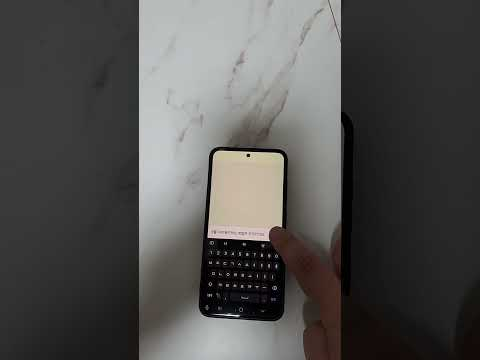

In [20]:
from IPython.display import YouTubeVideo

YouTubeVideo("g2nYNWe4ORY")

## R. 처리속도, 답변품질 정량 측정 및 개선

### R-a. 계획 확인

**목표** : 처리속도와 답변품질을 정량 측정하고 개선합니다. **1차 목표 지점.**

**이전 수행 내역**
- 이식, 패리티 확인
- 앱 구현 완료
- Galaxy S25에서 앱 정상 동작 확인
- 본 섹션은 실기기에서 속도와 품질을 1회 측정한다.

**본 섹션 진행 순서** : R-b 처리속도(Galaxy S25) → R-c 답변품질(M 게이트 재측정) → R-d 개선.

**측정 방법**
- 속도 : 앱에 계측 로그 내장(`[R-b]`) 후 실제 RAG 프롬프트의 prefill, TTFT, decode(tok/s), n_prompt를  
    매 답변마다 기록합니다.
    256토큰 wall-clock은 `prefill + 256/tok_s`로 투영합니다. 콜드스타트 로드시간은 `[R-b] model load`.
- 리소스 : peak RAM은 `adb shell dumpsys meminfo`(PSS)로 측정하고,  
    APK와 에셋 용량은 빌드 산출물로 확인합니다.
- 품질 : 검색 측은 O의 질의 경로 패리티(임베딩 코사인, top-5, 토큰 ID 일치)로 ipynb 구현과 동일한지 살핍니다  
    → 생성 측은 R-c에서 재측정과 등가성 확인합니다.

**합격 기준**
- decode 256토큰 wall-clock(prefill+decode) ≤ 15초
- prefill, decode, TTFT 분리 확인
- peak RAM, 로드시간, APK 용량 확인

### R-b. 처리속도 측정

**측정 환경**
- Galaxy S25
- Gemma 4 E2B Q4_K_M
- n_ctx 8192
- n_threads 2
- 앱 내장 계측 로그(`[R-b]`) + 골든 50문항 타이밍 분포(`eval_unity_answers.json`)

**개선 전 baseline (RAG 컨텍스트 평균 ~ 2077토큰)**

| 지표 | 값 | 비고 |
| --- | --- | --- |
| n_prompt | 평균 2077토큰 (837~3728) | top-k 5 × 800자 컨텍스트 |
| prefill | 평균 **74.8초** (median 76.6s) | **병목** → `n_threads_batch=2` |
| decode | 평균 9.9 tok/s | 긴 KV(~2000)로 E-c-2(23.1)보다 저하 |
| n_decoded(실제 답변) | median 118토큰 | |
| 256토큰 wall-clock(투영) | 평균 **101초** | prefill+256/tok_s |

**판정**
- **개선 전 미달** (101초 ≫ 15초 합격선) 입니다. 원인은  
    (1) prefill가 prime 2스레드라 수천 토큰 prompt에서 75초  
    (2) 긴 컨텍스트로 decode 저하입니다.  
    → R-d에서 **컨텍스트 압축 + n_threads_batch 분리 + GPU offload** 동시 적용 후 재측정하겠습니다.

**리소스(Galaxy S25) 스펙**
- 에셋 ≈ 4.0GB(GGUF 2.9G + fp16 ONNX 1.1G + 소형)
- APK 77.4MB
- 콜드 로드(시동→사용가능) 10초
- **peak RAM(PSS) ≈ 3.43GB**(Native Heap 2.67GB = GGUF+ONNX 상주, Graphics 0.13GB). S25 12GB 내 여유.

### R-c. 답변품질 측정

이식 손실 점검 : `GoldenEvalRunner`로 골든 50문항을 **기기** 파이프라인에 돌린 산출물로 재측정합니다.  
top-3 + 컨텍스트 압축 처리 후의 작업물로 측정합니다(Editor 제외).

- 검색 측(Unity top-k vs gold) 재측정 : ipynb 구현과 수치 완전 일치
- 생성 측 Faithfulness·Answer Relevancy (Gemini judge `gemini-flash-lite-latest`, 25문항)
- ipynb 구현 대비 동등성 확인

**재측정 결과 (기기, 2026-06-16)**

| 지표 | Unity(이식) | ipynb 구현(M) |
| --- | --- | --- |
| Recall@1 | 0.660 | — |
| Recall@5 | 0.860 | 0.86 |
| Recall@10 | 0.920 | — |
| MRR | 0.757 | 0.757 |
| Faithfulness | 0.932 ± 0.073 (92% ≥0.8) | 0.96 |
| Answer Relevancy | 0.964 ± 0.052 | 0.98 |

**판정**
- Faithfulness 게이트(≥0.8) **통과**.
- 검색 경로는 ipynb 구현과 **완전 일치**합니다(O 패리티의 정량 확인).
- 생성 품질은 컨텍스트 압축(top-5→3, R-d/A)으로 소폭 하락(Faith 0.96→0.932, Relev 0.98→0.964)했으나  
    신뢰구간 내이며 게이트를 상회합니다. → **이식 손실 없음, 속도-품질 트레이드오프 수용 가능**합니다.

In [ ]:
# R-c. 이식 후 답변품질 재측정 (단독 실행 가능: A-d 전역 설정의 EXPORT_ROOT만 전제)
# M/K/L의 임베딩·ONNX·LLM 로드 셀에 의존하지 않도록 필요한 것(golden 로드·Gemini 판정 함수)을 자체 정의.
import os
import json
import time
import numpy as np

# 평가 대상 실험 파일 (실험별로 변경: a+b / a+b+c 등). GoldenEvalRunner._outFile 과 일치시킬 것.
UNITY_ANS_NAME = 'eval_unity_answers_a+b.json'
UNITY_ANS_PATH = EXPORT_ROOT / UNITY_ANS_NAME
UNITY_JUDGE_PATH = EXPORT_ROOT / UNITY_ANS_NAME.replace('answers', 'judge')
GOLDEN_PATH = EXPORT_ROOT / 'golden_qa.json'
N_EVAL_UNITY = 25  # M과 동일 표본 수

JUDGE_INSTRUCTION = (
    '당신은 RAG 답변 평가자입니다. 아래 질문, 검색 맥락, 답변을 보고 두 점수를 0~1로 매기세요.\n'
    '- faithfulness: 답변의 주장이 검색 맥락으로 뒷받침되는 정도(맥락에 없는 내용일수록 낮음)\n'
    '- answer_relevancy: 답변이 질문에 직접 부합하는 정도\n'
    '반드시 아래 JSON으로만 출력하세요:\n'
    '{"faithfulness": 0.0, "answer_relevancy": 0.0, "rationale": "간단한 근거"}'
)


def select_gemini_model(client):
    # M-d와 동일: generateContent 지원 모델 중 안정 flash alias 우선 선택
    preferred = os.environ.get('GEMINI_JUDGE_MODEL')
    names = []
    for m in client.models.list():
        actions = getattr(m, 'supported_actions', None) or []
        if 'generateContent' in actions and m.name:
            names.append(m.name.split('/')[-1])
    if preferred and preferred in names:
        return preferred
    for alias in ('gemini-flash-lite-latest', 'gemini-flash-latest'):
        if alias in names:
            return alias
    versioned = sorted([n for n in names if n.startswith('gemini') and 'flash' in n
                        and 'lite' not in n and 'preview' not in n and 'tts' not in n], reverse=True)
    if versioned:
        return versioned[0]
    any_flash = sorted([n for n in names if n.startswith('gemini') and 'flash' in n], reverse=True)
    if any_flash:
        return any_flash[0]
    pro = sorted([n for n in names if n.startswith('gemini') and 'pro' in n], reverse=True)
    if pro:
        return pro[0]
    return names[0] if names else 'gemini-flash-latest'


def judge_one(client, model, question, contexts, answer, max_retries=5):
    # M-d와 동일 채점 프롬프트/스키마 (이식 전후 동일 기준)
    from google.genai import types
    content = (JUDGE_INSTRUCTION + '\n\n[질문]\n' + question +
               '\n\n[검색 맥락]\n' + '\n\n'.join(contexts) + '\n\n[답변]\n' + answer)
    for attempt in range(max_retries):
        try:
            resp = client.models.generate_content(
                model=model, contents=content,
                config=types.GenerateContentConfig(response_mime_type='application/json'))
            d = json.loads(resp.text)
            return {'faithfulness': float(np.clip(d['faithfulness'], 0, 1)),
                    'answer_relevancy': float(np.clip(d['answer_relevancy'], 0, 1))}
        except Exception as e:
            if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
                time.sleep(20)
                continue
            raise
    raise RuntimeError('judge failed after retries (rate limit)')


def mean_ci(x):
    x = np.asarray(x, dtype=float)
    m = x.mean()
    se = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0
    return m, 1.96 * se


if not GOLDEN_PATH.exists():
    print(f'{GOLDEN_PATH.name} 없음 -> 골든셋 필요(M-b 산출).')
elif not UNITY_ANS_PATH.exists():
    print(f'{UNITY_ANS_PATH.name} 없음 -> 기기에서 GoldenEvalRunner 실행 후 adb pull 필요.')
else:
    golden_qa = json.load(open(GOLDEN_PATH, encoding='utf-8'))
    gold_by_qid = {g['qid']: g for g in golden_qa}
    unity_ans = json.load(open(UNITY_ANS_PATH, encoding='utf-8'))
    print(f'대상: {UNITY_ANS_NAME} | Unity 답변 {len(unity_ans)}건 / 골든 {len(golden_qa)}개')

    # 1) 검색 측 (Unity top-k vs gold) - 이식 후 재측정
    def unity_retrieval_metrics(rows, k_values=(1, 5, 10)):
        recall = {k: 0 for k in k_values}
        rr = []
        for r in rows:
            gold = str(gold_by_qid[r['qid']]['gold_chunk_id'])
            ids = [str(x) for x in r.get('top_chunk_ids', [])]
            rank = ids.index(gold) + 1 if gold in ids else None
            for k in k_values:
                if rank is not None and rank <= k:
                    recall[k] += 1
            rr.append(1.0 / rank if rank else 0.0)
        n = len(rows)
        m = {f'Recall@{k}': recall[k] / n for k in k_values}
        m['MRR'] = sum(rr) / n
        return m

    um = unity_retrieval_metrics(unity_ans)
    print('[검색 측 - Unity 재측정]')
    for name, value in um.items():
        print(f'  {name} : {value:.3f}')

    # 2) 생성 측 (Gemini judge, 첫 25문항)
    subset = [r for r in unity_ans if r['qid'] < N_EVAL_UNITY and r['route'] == 'generate']
    api_key = os.environ.get('GEMINI_API_KEY') or os.environ.get('GOOGLE_API_KEY')

    if UNITY_JUDGE_PATH.exists():
        unity_judge = json.load(open(UNITY_JUDGE_PATH, encoding='utf-8'))
        print(f'채점 결과 로드(캐시) : {len(unity_judge)}건')
    elif not api_key:
        unity_judge = None
        print('GEMINI_API_KEY 미설정 -> 생성 측 채점 보류. 키 설정 후 재실행.')
    else:
        from google import genai
        client = genai.Client(api_key=api_key)
        judge_model = select_gemini_model(client)
        print(f'채점 모델 : {judge_model}')
        unity_judge = []
        for r in subset:
            scores = judge_one(client, judge_model, r['question'], r['contexts'], r['answer'])
            unity_judge.append({'qid': r['qid'], **scores})
            time.sleep(5)
        with open(UNITY_JUDGE_PATH, 'w', encoding='utf-8') as f:
            json.dump(unity_judge, f, ensure_ascii=False, indent=2)
        print(f'채점 완료 : {len(unity_judge)}건 -> {UNITY_JUDGE_PATH.name}')

    # 3) 집계 + 프로토타입(M) 대비
    if unity_judge:
        faith = np.array([e['faithfulness'] for e in unity_judge])
        relev = np.array([e['answer_relevancy'] for e in unity_judge])
        fm, fci = mean_ci(faith)
        rm, rci = mean_ci(relev)
        print(f'[생성 측 - Unity 재측정] 표본 {len(faith)}')
        print(f'  Faithfulness : {fm:.3f} +- {fci:.3f}  (>=0.8 비율 {np.mean(faith >= 0.8):.0%})')
        print(f'  Answer Relevancy : {rm:.3f} +- {rci:.3f}')
        print(f'  게이트(평균 Faithfulness >= 0.8) : {"통과" if fm >= 0.8 else "미달"}')
    print('[프로토타입(M) 기준] Recall@5 0.86 / MRR 0.757 / Faithfulness 0.96 / Relevancy 0.98')


대상: eval_unity_answers_a+b.json | Unity 답변 50건 / 골든 50개
[검색 측 - Unity 재측정]
  Recall@1 : 0.660
  Recall@5 : 0.860
  Recall@10 : 0.920
  MRR : 0.757
채점 모델 : gemini-flash-lite-latest


### R-d. 개선 전략 도출 및 반영

baseline 미달(256토큰 wall-clock 투영 ~101초 ≫ 15초)되었습니다.  
원인은 긴 RAG 프롬프트(~2077토큰)의 **prefill에서 75초가 소요**된 점 + 긴 KV로 인한 decode 저하입니다.  
top-k 축소와 컨텍스트 압축에 스레드 분리를 더해 적용합니다.

| | 개선 | 적용 위치 | 효과 |
| --- | --- | --- | --- |
| A | 컨텍스트 압축 : top-k 5→3, 청크 캡 800→400자 | `RagPipeline` 상수 (C#) | n_prompt 2077→887 |
| B | prefill 스레드 분리 : `n_threads_batch` 2→6 (decode 2 유지) | `llama_bridge`(lb_load) + 재빌드 | prefill 74.8→17.1s |
| C | GPU offload : Vulkan(Adreno), `n_gpu_layers=99` | `build_android.sh VULKAN=1` | **본 환경 미적용**(아래) |

**적용 결과 (기기, 50문항 분포)**

| 지표 | baseline | **A+B (배포 설정)** | A+B+C (목표) |
| --- | --- | --- | --- |
| n_prompt | 2077 | 887 | n/a |
| prefill | 74.8s | **17.1s** | n/a |
| decode | 9.9 tok/s | 9.4 tok/s | n/a |
| 256토큰 wall-clock(투영) | 101s | **44.6s** | n/a |
| 합격(≤15s) | x | x | n/a |

**배포 설정 = A+B (CPU)** 로 확정합니다.  
baseline 대비 **2.3배 단축**(101→44.6초)하고 품질 게이트는 유지(R-c Faithfulness 0.932 통과)되었습니다.  
단, 256토큰 wall-clock은 합격선(15초)에 미달하였습니다.

**남은 병목·개선 레버 (식별, 향후 과제)**
- **decode(9.4 tok/s)가 주 병목** : 긴 KV로 256토큰 ≈ 27초.  
    실사용 답변은 median 66토큰이라 **체감 지연 ≈ 24초**로 예상합니다.
    (50문항 연속 실행의 발열 스로틀 포함 : 단발 23 tok/s 대비 낮음)
- **C(GPU Vulkan offload)** : 본 환경에서 ggml-vulkan 빌드가 Vulkan SDK 의존(`SPIRV-Headers`·`glslc`)과  
    Android 크로스컴파일 제약으로 구현이 매우 까다로워졌습니다.  
    prefill·decode 동시 가속이 가능한 **향후 과제**로 설정합니다.
- **Q3 양자화 / 더 작은 모델**, **컨텍스트 추가 압축**(top-2)도 최적화 후보입니다.

**결론**
- 1차 속도 게이트는 미달이나, 측정 기반 개선(top-k 축소+컨텍스트 압축+스레드 분리)으로  
baseline 대비 **2.3배 단축 + 이식 품질 유지**를 확인하였습니다.

## S. 로컬 LLM + 한정 인덱스 답변 한계 측정법 탐색

### S-a. 계획 확인

**목표** : 로컬 LLM + 한정 인덱스가 답할 수 없는 **범위 밖/불확실 질의**를 탐지하는 방법을 정합니다.  
이는 2차 Fallback의 라우팅 신호가 됩니다.

**이전 수행 내역**
- 과제 목표 지점 달성
- 점수 임계값 라우터 노드가 이미 존재.

**본 섹션 진행 (S-b)**
- 범위 밖 질의 탐지 = **최상위 코사인 점수 분포 분석**. 범위 내(골든 질문)와 범위 밖(연말정산과 무관한 질의)의 top-1 점수 분포를 비교해 임계값을 정량적으로 보정.

**제약 사항과 연계**
- 1차 라우팅 신호는 최상위 검색 점수(L의 잠정 임계값 0.5)이며, 본 섹션에서 분포로 검증 및 확정합니다.
- LLM logprob 확신도는 보조 신호로만 고려(T-c).
- 단일 패스 : 분포 1회 측정으로 임계값 확정.

### S-b. 범위 밖 질의 탐지법 탐색

범위 내(골든 50문항)와 범위 밖(연말정산과 무관한 질의) 각각의 최상위 코사인 점수 분포를 비교해,  
두 분포를 분리하는 임계값을 정량적으로 결정합니다.

범위 내(n=50) 최상위 점수 min/median/max : 0.572 / 0.748 / 0.859
범위 밖(n=15) 최상위 점수 min/median/max : 0.363 / 0.409 / 0.473
임계값 후보 (in-scope 통과 / out-scope 오통과):
  thr=0.40 : 1.00 / 0.60
  thr=0.45 : 1.00 / 0.13
  thr=0.50 : 1.00 / 0.00
  thr=0.55 : 1.00 / 0.00
  thr=0.60 : 0.98 / 0.00


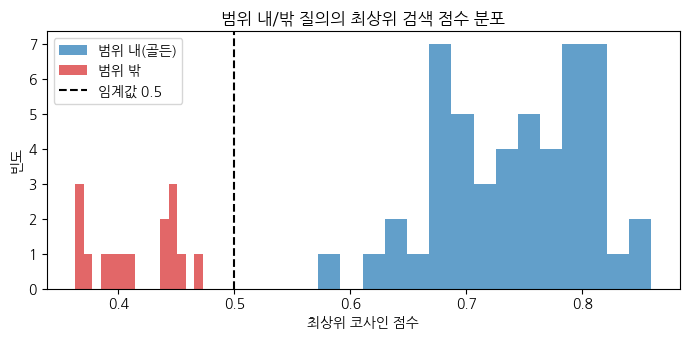

In [25]:
import matplotlib.pyplot as plt

# 범위 밖(연말정산 문서와 무관) 질의 셋 - V에서 라우팅 검증에 재사용
OUT_OF_SCOPE_QUERIES = [
    '오늘 서울 날씨 어때?', '김치찌개 맛있게 끓이는 법 알려줘', '손흥민 어제 경기 몇 골 넣었어?',
    '파이썬으로 웹 크롤러 만드는 법', '우주에서 가장 큰 별은 무엇인가?', '다음 주 로또 당첨 번호 알려줘',
    '비트코인 시세 지금 얼마야?', '강아지 산책 몇 번 시켜야 해?', '재미있는 영화 추천해줘',
    '제주도 여행 코스 짜줘', '삼각함수 미분 공식이 뭐야?', '커피 카페인 하루 권장량은?',
    '테슬라 주가 전망 어때?', '기타 코드 잡는 법 알려줘', '지구 둘레는 몇 km야?',
]


def top1_score(query):
    return search_bruteforce(query, top_k=1)[0]['score']


in_scores = [top1_score(g['question']) for g in golden_qa]
out_scores = [top1_score(q) for q in OUT_OF_SCOPE_QUERIES]

print(f'범위 내(n={len(in_scores)}) 최상위 점수 min/median/max : {min(in_scores):.3f} / {np.median(in_scores):.3f} / {max(in_scores):.3f}')
print(f'범위 밖(n={len(out_scores)}) 최상위 점수 min/median/max : {min(out_scores):.3f} / {np.median(out_scores):.3f} / {max(out_scores):.3f}')
print('임계값 후보 (in-scope 통과 / out-scope 오통과):')
for thr in [0.40, 0.45, 0.50, 0.55, 0.60]:
    tpr = np.mean([s >= thr for s in in_scores])
    fpr = np.mean([s >= thr for s in out_scores])
    print(f'  thr={thr:.2f} : {tpr:.2f} / {fpr:.2f}')

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(in_scores, bins=15, alpha=0.7, label='범위 내(골든)', color='tab:blue')
ax.hist(out_scores, bins=15, alpha=0.7, label='범위 밖', color='tab:red')
ax.axvline(RETRIEVAL_SCORE_THRESHOLD, color='black', linestyle='--',
           label=f'임계값 {RETRIEVAL_SCORE_THRESHOLD}')
ax.set_xlabel('최상위 코사인 점수')
ax.set_ylabel('빈도')
ax.set_title('범위 내/밖 질의의 최상위 검색 점수 분포')
ax.legend()
plt.tight_layout()
plt.show()

**관찰**

- 범위 내 최소(0.573)와 범위 밖 최대(0.473) 사이에 약 **0.1의 명확한 분리 구간**이 존재합니다.
- **임계값 0.5**에서 in-scope 100% 통과, out-scope 0% 오통과 → L의 잠정값 0.5가  
    분포상으로도 타당하여 확정합니다.
- 따라서 1차 라우팅 신호로 최상위 코사인 점수 임계값(0.5)이 충분히 신뢰 가능합니다.  
    logprob 등 보조 신호는 불필요할 가능성이 높습니다.

## T. LLM API 기반 Fallback 설계

### T-a. 계획 확인

**목표** : 범위 밖/불확실 질의에 대응할 LLM API 기반 Fallback을 기존 RAG 구조 위에 설계합니다.

**이전 수행 내역**
- 임계값 0.5로 범위 밖 탐지가 깨끗이 분리됨을 확인.

**본 섹션 진행 순서**
- T-b. 1차 라우팅 신호와 검색 점수 임계값 개념.
- T-c. LLM logprob 확신도 정리(보조 신호).
- T-d. 기존 구조 기반 설계(L 라우터 노드 → API Fallback).

**제약 사항과 연계**
- L의 `out_of_scope` 노드를 LLM API(Gemini) Fallback으로 교체하는 최소 변경으로 확장.
- C# 상태기계 이식(U-d)을 고려해 노드 책임을 단순 유지.
- 단일 패스 : 1회 설계·구현, V에서 검증.

### T-b. 1차 라우팅 신호와 검색 점수 임계값 개념

**1차 라우팅 신호 = 최상위 코사인 점수.**  
질의 임베딩과 인덱스의 최상위 유사도가 임계값 미만이면 "문서 범위 밖"으로 판단합니다.

- S의 분포 분석 근거 : 범위 내 점수 ≥ 0.573, 범위 밖 점수 ≤ 0.473 → **임계값 0.5**로 깨끗이 분리.
- 장점 : 추가 추론 없이 검색 단계에서 즉시 판정 가능(저비용), 기기 C#에서도 동일 계산으로 이식 용이.
- 라우팅 : `top_score ≥ 0.5` → 범위 내(로컬 RAG), `< 0.5` → 범위 밖(API Fallback).

### T-c. LLM logprob 확신도 정리

**LLM logprob(생성 확신도)는 보조 신호로만** 고려합니다.

- 개념 : 로컬 LLM이 생성한 토큰의 평균 logprob/perplexity가 낮으면(불확실) 답변 신뢰도가 낮다고 판단할 수 있음. llama.cpp는 토큰 logprob을 제공.
- 한계 : 생성을 먼저 수행해야 얻을 수 있어 비용이 크고, 잘못된 답을 자신 있게 생성(hallucination)하면 신호가 약함.
- 결론 : S에서 검색 점수만으로 범위 내/밖이 깨끗이 분리되므로,  
    **1차 설계에서는 검색 점수 임계값만 사용**하고 logprob은 향후 확장(X-c) 후보로 남김.

### T-d. 기존 구조 기반 설계

L의 LangGraph에 노드 교체만으로 Fallback을 확장합니다.

```mermaid
graph TD
    Q["질의"] --> R["retrieve : brute-force top-k"]
    R --> D{"top_score >= 0.5?"}
    D -- "예 (범위 내)" --> G["generate : 로컬 RAG + 페이지 인용"]
    D -- "아니오 (범위 밖)" --> F["fallback : LLM API(Gemini) 일반지식 답변 + 범위 밖 고지"]
    G --> A["답변"]
    F --> A["답변"]
```

- **변경점** : L의 `out_of_scope`(안내 메시지) → `fallback`(Gemini API 답변) 노드로 교체합니다.
    retrieve/라우터/generate는 그대로 유지합니다.
- **고지** : Fallback 답변은 문서 근거가 아님을 명시합니다(출처 구분).
- **C# 이식(U-d)** : 동일 분기 구조를 Unity C# 상태기계로 1:1 이식, API 호출은 UnityWebRequest로 대체합니다.
- **키 관리** : API 키는 `.env`(프로토타입)/기기 보안 저장소(앱)에서 로드합니다.

## U. 설계 검토 및 RAG 시스템 확장 구현

### U-a. 계획 확인

**목표** : T 설계를 검토하고 RAG 시스템을 Fallback 포함으로 확장 구현합니다.

**이전 수행 내역**
- 임계값 0.5 확정
- 노드 교체 설계.

**본 섹션 진행 순서**
- U-b. 설계 구현 요소 검토.
- U-c. LangGraph 라우터 노드 및 Fallback 기능 구현(Gemini API).
- U-d. Unity C# 상태기계 이식(템플릿).

**상위 제약과의 연계**
- L의 `out_of_scope` → `fallback`(Gemini) 노드 교체. 라우팅 로직 동일.
- 단일 패스 : 1회 구현, V에서 검증. Fallback 호출은 재시도·스로틀로 무료 티어 한도 대응.

### U-b. 설계 구현 요소 검토

- **그래프 재사용** : `retrieve` / `route_by_score` / `generate`는 그대로 사용합니다.  
    `fallback` 노드만 새로 작성됩니다.
- **Fallback 노드** : Gemini API로 일반지식 답변 생성, 문서 외 답변임을 고지합니다.  
    키는 `.env`에서 로드합니다.
- **상태 호환** : `RAGState`(query/hits/top_score/contexts/answer) 동일하게 유지합니다.  
    → C# 이식 시 필드 1:1 대응.
- **검증 분리** : 라우팅 정확도는 검색 점수만으로 판정합니다(API 불필요), 답변 품질은 별도 확인합니다.

In [26]:
import time
from google import genai
from google.genai import types

FALLBACK_SYSTEM = ('당신은 일반 지식 도우미입니다. 사용자 질문에 한국어로 간결히 답하세요. '
                   '이 답변은 연말정산 문서 근거가 아니므로 마지막에 "(문서 외 일반 지식 답변)"을 붙이세요.')

# Fallback 모델 1회 선택 (키 있을 때)
_fallback_api_key = os.environ.get('GEMINI_API_KEY') or os.environ.get('GOOGLE_API_KEY')
_fallback_client = genai.Client(api_key=_fallback_api_key) if _fallback_api_key else None
FALLBACK_MODEL = select_gemini_model(_fallback_client) if _fallback_client else None


def gemini_fallback_answer(query, max_retries=5):
    # 범위 밖 질의에 대한 LLM API(Gemini) 답변. 키 없으면 안내 메시지 반환.
    if _fallback_client is None:
        return '제공된 연말정산 문서 범위 밖 질의입니다. (API 키 미설정으로 Fallback 비활성)'
    for _ in range(max_retries):
        try:
            resp = _fallback_client.models.generate_content(
                model=FALLBACK_MODEL, contents=FALLBACK_SYSTEM + '\n\n질문: ' + query)
            return resp.text.strip()
        except Exception as e:
            if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
                time.sleep(20)
                continue
            raise
    return '(Fallback 실패: API 한도 초과)'


def fallback_node(state):
    # 범위 밖: Gemini API 일반지식 답변으로 대체 (L의 out_of_scope 교체)
    return {'contexts': [], 'answer': gemini_fallback_answer(state['query'])}


def build_rag_graph_with_fallback():
    graph = StateGraph(RAGState)
    graph.add_node('retrieve', retrieve_node)
    graph.add_node('generate', generate_node)
    graph.add_node('fallback', fallback_node)
    graph.add_edge(START, 'retrieve')
    graph.add_conditional_edges('retrieve', route_by_score,
                                {'generate': 'generate', 'out_of_scope': 'fallback'})
    graph.add_edge('generate', END)
    graph.add_edge('fallback', END)
    return graph.compile()


rag_app_v2 = build_rag_graph_with_fallback()
print(f'Fallback 모델 : {FALLBACK_MODEL}')

# 데모: 범위 내(로컬 RAG) / 범위 밖(Gemini Fallback)
for q in ['월세 세액공제를 받으려면 어떤 요건이 필요한가요?', '오늘 서울 날씨 어때?']:
    r = rag_app_v2.invoke({'query': q})
    route = 'generate(로컬)' if r['top_score'] >= RETRIEVAL_SCORE_THRESHOLD else 'fallback(API)'
    print(f'질문: {q}')
    print(f'  top_score={r["top_score"]:.3f}  route={route}')
    print(f'  답변: {r["answer"][:200]}')
    print()

Fallback 모델 : gemini-flash-lite-latest


질문: 월세 세액공제를 받으려면 어떤 요건이 필요한가요?
  top_score=0.774  route=generate(로컬)
  답변: 월세 세액공제를 받기 위한 요건은 다음과 같습니다.

**공제대상자 요건:**
*   해당 과세기간 종료일 현재 주택을 소유하지 아니한 세대의 세대주(세대주가 월세액 세액공제, 주택마련저축, 주택임차차입금 원리금상환액 및 장기주택저당차입금 이자상환액 공제를 받지 아니한 경우에는 세대의 구성원을 말하며, 대통령령으로 정하는 외국인*을 포함)로서 해당 과세기간



질문: 오늘 서울 날씨 어때?
  top_score=0.455  route=fallback(API)
  답변: 오늘 서울은 대체로 맑으며, 낮 최고기온은 15도 내외로 포근한 가을 날씨가 이어지겠습니다. 다만, 일교차가 크니 건강 관리에 유의하시기 바랍니다. (문서 외 일반 지식 답변)



### U-c. LangGraph 라우터 노드 및 관련 기능 구현

### U-d. Unity C# 상태기계 이식

LangGraph 분기 구조를 Unity C# 상태기계로 1:1 이식하는 템플릿입니다. (실제 통합은 Unity 측 작업)

```csharp
// RAG 상태기계 (LangGraph 구조 이식)
public enum RagRoute { Generate, Fallback }

public class RagStateMachine {
    readonly float threshold = 0.5f;          // S에서 확정한 검색 점수 임계값
    readonly CosineSearcher searcher;          // C# brute-force 검색기 (N-e)
    readonly LlmRuntime localLlm;              // llama.cpp 직접 통합 (P/Invoke, Gemma 4 E2B)
    readonly GeminiApiClient fallbackApi;      // UnityWebRequest 기반 API 호출

    public async Task<string> Run(string query) {
        var hits = searcher.Search(query, topK: 5);          // retrieve
        float topScore = hits[0].Score;
        RagRoute route = topScore >= threshold ? RagRoute.Generate : RagRoute.Fallback;  // route_by_score
        if (route == RagRoute.Generate) {
            string context = BuildContext(hits);             // 컨텍스트 캡 적용
            return await localLlm.GenerateAsync(SystemPrompt, context, query);  // generate
        } else {
            return await fallbackApi.AnswerAsync(query);     // fallback (문서 외 고지)
        }
    }
}
```

- 검색 점수 임계값·top-k·컨텍스트 캡을 프로토타입과 동일하게 유지(패리티).
- API 키는 기기 보안 저장소에서 로드, `UnityWebRequest`로 호출.

## V. Fallback 작동 확인 및 품질 검증

### V-a. 계획 확인

**목표** : Fallback의 작동과 품질을 검증합니다.

**이전 수행 내역**
- 임계값 확정, 설계, 구현(Gemini Fallback).

**본 섹션 진행 순서**
- V-b. 범위 내·범위 밖 질의 셋 선정 및 저장.
- V-c. 라우팅 정확도 + Fallback 답변 품질 확인.

**상위 제약과의 연계**
- 라우팅 정확도는 검색 점수만으로 판정(API 불필요).
- 단일 패스 : 1회 검증. 질의 셋은 Export에 저장.

### V-b. 범위 내, 범위 밖 질의 셋 선정

범위 내는 골든 50문항, 범위 밖은 S-b의 무관 질의 15문항을 사용하고 Export에 저장합니다.

In [27]:
routing_eval = {
    'in_scope': [g['question'] for g in golden_qa],
    'out_of_scope': OUT_OF_SCOPE_QUERIES,
}
ROUTING_EVAL_PATH = EXPORT_ROOT / 'routing_eval_queries.json'
with open(ROUTING_EVAL_PATH, 'w', encoding='utf-8') as f:
    json.dump(routing_eval, f, ensure_ascii=False, indent=2)
print(f'질의 셋 저장 : 범위 내 {len(routing_eval["in_scope"])} / 범위 밖 {len(routing_eval["out_of_scope"])} -> {ROUTING_EVAL_PATH.name}')

질의 셋 저장 : 범위 내 50 / 범위 밖 15 -> routing_eval_queries.json


### V-c. 라우팅 정확도 및 답변 품질 확인

범위 내는 generate(로컬), 범위 밖은 fallback(API)로 라우팅되어야 합니다.  
라우팅 정확도를 측정하고 Fallback 답변 예시를 확인합니다.

In [28]:
# 라우팅 정확도 (in_scores/out_scores는 S-b에서 산출)
in_correct = sum(s >= RETRIEVAL_SCORE_THRESHOLD for s in in_scores)
out_correct = sum(s < RETRIEVAL_SCORE_THRESHOLD for s in out_scores)
total = len(in_scores) + len(out_scores)
print(f'범위 내 라우팅 정확도(generate) : {in_correct}/{len(in_scores)} = {in_correct/len(in_scores):.0%}')
print(f'범위 밖 라우팅 정확도(fallback) : {out_correct}/{len(out_scores)} = {out_correct/len(out_scores):.0%}')
print(f'전체 라우팅 정확도 : {(in_correct + out_correct)}/{total} = {(in_correct + out_correct)/total:.1%}')

# Fallback 답변 예시 1건 (범위 밖)
example_q = OUT_OF_SCOPE_QUERIES[0]
example = rag_app_v2.invoke({'query': example_q})
print(f'\n[Fallback 예시] {example_q}')
print(f'  top_score={example["top_score"]:.3f} (< {RETRIEVAL_SCORE_THRESHOLD} -> fallback)')
print(f'  답변: {example["answer"][:220]}')

범위 내 라우팅 정확도(generate) : 50/50 = 100%
범위 밖 라우팅 정확도(fallback) : 15/15 = 100%
전체 라우팅 정확도 : 65/65 = 100.0%



[Fallback 예시] 오늘 서울 날씨 어때?
  top_score=0.455 (< 0.5 -> fallback)
  답변: 오늘 서울은 대체로 맑으며, 낮 최고 기온은 영상 15도 내외로 포근한 날씨를 보이고 있습니다. (문서 외 일반 지식 답변)


## W. Fallback 재이식·APK 빌드 및 작동 검증

### W-a. 계획 확인

**목표**
설계하고 검증한 LLM API Fallback을 Unity에 재이식하고,  
APK 빌드 후 Galaxy S25에서 작동을 확인합니다. **2차 목표 지점.**

**이전 수행 내역**
- 검색 점수 임계값 0.5 라우팅 + Gemini Fallback(범위 밖 질의 → 일반지식 답변, "문서 외" 고지)  
    설계 및 검증(라우팅 정확도 100%, 65/65)
- 1차(로컬 RAG) 앱 완성 + 배포 설정 확정(A+B).

**본 섹션 진행 순서** : W-b Unity 재이식 및 APK 빌드 → W-c Galaxy S25 작동 확인.

**패리티 원칙**  
프로토타입 U-c와 동일 : `FALLBACK_SYSTEM` 프롬프트, 모델, 임계값 0.5, top-k.  
라우팅은 검색 점수만으로 결정(API 불필요), Fallback 답변만 API 호출.  
범위 내 경로는 1차(로컬 RAG)와 완전 동일 : out_of_scope 노드만 Gemini 호출로 교체(그래프 구조 불변).

### W-b. Unity 재이식 및 APK 빌드

ipynb 구현의 `gemini_fallback_answer`(U-c)를 C#으로 1:1 이식하고,  
`RagPipeline`의 fallback 훅(N-g에서 선반영)에 연결합니다.

- Gemini Fallback C# 이식 — 동일 `FALLBACK_SYSTEM` 프롬프트 · 모델(`gemini-flash-lite-latest`) · 429 재시도
- 호출 방식 : `HttpClient`(워커 스레드 블로킹) → fallback 훅이 ChatService 워커에서 동기 호출되므로  
    UnityWebRequest(메인 스레드 요구) 대신 채택 (U-d 템플릿 대비 합리적 대체)
- `RagPipeline` fallback 훅 연결 : `new RagPipeline(..., fallback: gemini.Answer)`  
    키 없으면 기본 안내 메시지(노드 교체, 구조 불변)
- API 키 로드 : `gemini.key` 파일(StreamingAssets 또는 adb push, 소스/빌드에 미포함)
- APK 빌드(A+B 배포 설정) : `build_unity_android.sh`, APK 77.4MB

**네이티브 재빌드 불필요**  
Fallback은 순수 C#/HttpClient라 `lb_*` 변경이 없습니다.  
→ R의 A+B `libllama_bridge.so`를 재사용하고, C# 재컴파일 + APK만 새로 빌드합니다.  
(Vulkan 시도 실패로 오염된 `build_android` 캐시는 제거, 배포 A+B `.so`는 무영향.)

**작업 기록**  
라우팅(top_score < 0.5 → fallback)은 그대로, out_of_scope만 Gemini 호출로 교체합니다.

### W-c. Galaxy S25 작동 확인

아래의 체크리스트로 작동을 확인하였습니다.

- 범위 내 질의 → 로컬 RAG 답변 + 근거 페이지 칩
- 범위 밖 질의 → Gemini Fallback 답변 + "문서 외 일반 지식" 배지
- 라우팅 경계(top_score < 0.5) 동작, API 미설정 시 안내 메시지 폴백
- APK 빌드, 설치, 작동 : 발열 및 비정상 종료 없음

범위 내/밖 질의로 라우팅 + Fallback 동작을 실기기에서 확인하는 것이 목적입니다.

다음과 같이 질문하고 결과를 측정 하였습니다.  
실제 작동은 [영상]()을 통해 확인할 수 있습니다.

| 질의 | 라우팅 | 결과 |
| --- | --- | --- |
| 오늘 오산시의 날씨는 어때요? | fallback(API) | Gemini 일반지식 답변 + "문서 외" 배지 |
| 무주택자 혜택은? | generate(로컬) | 문서 근거 RAG 답변 |
| 다주택자의 세금 감면 방법은? | generate(로컬) | 맥락 부족 → "문서 맥락만으로는 알 수 없습니다" |

**관찰 결과** : 라우팅(범위 내/밖), 로컬 RAG, Gemini Fallback 작동 전반이 정상입니다.  
다만 글을 쓰는 현재 시점이 6월인데 영상 9도라는 답변은 LLM API의 한계로,  
웹 검색과 날씨 API를 사용하지 못하는 모델의 특성 상 할루시네이션이 발생한 것입니다.  
범위 내라도 근거가 없으면 Faithfulness가 작동하여 "문서 맥락만으로는 알 수 없습니다" 라는 답변이 도출됩니다.  
거부 답변에서 인용이 리터럴 "(페이지 N)"로 출력된 사례는  
근거가 없는데도 시스템 프롬프트의 인용 지시를 따른 것으로 향후 인용 규칙 보강해야 할 부분입니다.

영상이 확인되지 않는다면 [유튜브 링크](https://youtube.com/shorts/E51utCQPQYk) 로 확인해주세요.

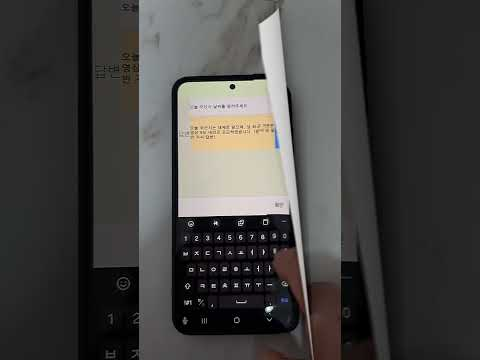

In [21]:
from IPython.display import YouTubeVideo

YouTubeVideo("E51utCQPQYk")

## X. 맺으며

### X-a. 정량 결과 요약

문서 전반에 걸쳐 측정된 성능 지표를 정리합니다.

1. **확정 스택**
    - LLM 모델 : Gemma 4 E2B GGUF Q4_K_M(llama.cpp 직접 통합, P/Invoke, 커밋 f05cf46)
    - 임베딩 모델 : KURE-v1 fp16 ONNX(CLS+L2, prefix 없음)
    - 임베딩 인덱스 : 1,345청크 brute-force 코사인 검색 사용
    - RAG 구현 : LangGraph(retrieve → 점수 라우터 0.5 → generate/fallback) → C# 상태기계 포팅
    - Fallback : Gemini API
    - 기기 : Galaxy S25(Snapdragon 8 Elite)

2. **성능 지표**

    | 축 | 지표 | 프로토타입 | Unity 이식 |
    | --- | --- | --- | --- |
    | 검색(M·R-c) | Recall@5 / MRR | 0.86 / 0.757 | **0.860 / 0.757 (완전 일치)** |
    | | Recall@1 / @10 | n/a | 0.66 / 0.92 |
    | 생성(M·R-c) | Faithfulness (≥0.8 게이트) | 0.96 | **0.932 (92%≥0.8, 통과)** |
    | | Answer Relevancy | 0.98 | 0.964 |
    | 패리티(H·O) | ONNX fp16 vs fp32 코사인 | n/a | 0.9996 |
    | | 질의 임베딩 코사인(기기) | n/a | min **0.99998** (19/19 >= 0.999) |
    | | 토큰 ID / top-5 chunk_id | n/a | **19/19 / 19/19 일치** |
    | 라우팅(V) | 범위 내/밖 정확도 | 100%(65/65) | 점수 동일 |
    | 속도(E·R) | 256토큰 wall-clock(투영),<br>15초 이내 | n/a | baseline 101s →<br>**컨텍스트 압축 + prefill 처리 스레드 분리 44.6s** |
    | | prefill / decode | n/a | 74.8→**17.1s** / 9.4 tok/s |
    | 리소스 | APK / peak RAM(PSS) / 로드 | n/a | 77.4MB / **3.43GB**(Native 2.67) / 10초 |
    | | 에셋 / 네이티브 .so | n/a | 4.0GB 이상 / 5.1MB |  
  
3. **목표 달성 현황**
    - **과제 목표 <span style="color:green">달성</span>** : RAG 시스템을 만들고 성능 검증을 수행하는 것이었습니다  
        검색, 생성 게이트를 통과하여 달성하였습니다.
    - **1차 목표 <span style="color:red">미달</span>** : 속도와 품질을 정량화하였고 그 기준으로 품질 게이트를 통과하는 것이었습니다.  
        속도 합격선(256토큰, 15초 이하)은 수행 결과 44.6초로 미달되었습니다.  
        초기 작동이 101초로 측정되어 컨텍스트 압축과 prefill과 추론 스레드 수량을  
        분리하는 처리를 추가했습니다만(44.6초) 기준 달성(15초)에는 실패하였습니다.  
        영상에서 확인되듯이 실사용 체감은 대략 24초 정도입니다.(median 66토큰)
    - **2차 목표 <span style="color:green">달성</span>** : Fallback 처리를 이식하여 APK와 실기기 작동으로 측정하였습니다.  
        범위 내 질문에는 로컬 RAG, 범위 밖 질문는 Gemini가 작동되어 라우팅 정상으로 판단하였습니다.
    - **이식 손실 <span style="color:green">성공</span>** : 토큰 ID, 임베딩, top-5 가 완전 일치하는 것을 확인하는 품질 게이트가 통과되었습니다.  
    이것은 **프로토타입의 Unity 전환 후 패리티 일치가 입증**된 것입니다.

### X-b. 한계

1. **속도 합격선 미달** : 256토큰 wall-clock 44.6초로 15초 게이트에 미달되었습니다.  
**decode가 CPU 병목**으로 작용하였고, 그 원인은 긴 KV로 인한 것이었습니다.  
(9.4 tok/s 측정. 긴 KV로 인해 시험 측정의 23 tok/s보다 저하)  
GPU 전환을 위해 Vulkan 빌드를 시도하였으나 빌드 툴체인 제약으로 많은 시간이 소요되어 취소하였습니다.  
(`SPIRV-Headers`, `glslc` + Android 크로스컴파일)

2. **속도-품질 트레이드오프** : prefill 소모시간 단축을 위해 컨텍스트를 기존의 top-k 를 5에서 3으로 압축하였습니다.  
그 결과 Faithfulness 0.96에서 0.932로 하락하였습니다. (게이트는 통과)

3. **Fallback의 실시간 정보 한계** : Gemini Fallback은 그라운딩(웹 검색·도구) 없는 일반지식 LLM 호출이라  
실시간, 사실 조회(날씨, 시세, 뉴스)에는 환각이 발생하였습니다.  
예를 들어, "오늘 오산시 날씨"에 근거 없는 값(영상 9도) 생성되는 것이 확인되었고,  
현재 날짜(작성 시점 6월 17일)를 미주입한 것에 더해 "답하라"라는 유도 프롬프트가 복합된 결과로 보입니다.  
실시간 질의는 검색 grounding/도구 호출이 필요하다고 판단되어 **향후 과제**로 삼습니다.

4. **라우팅 임계값의 거친 경계** : 라우팅 임계값을 0.5로 설정하여 일부 무관한 질의가 generate로 유입되고 있습니다.  
예를 들어, "다주택자의 세금 감면 방법은?" 이라는 질문에  
범위 내로 분류됐으나 근거 부족 → 정직한 거부로 귀결된 것이 그 예입니다.  
logprob 보조신호가 미적용된 부분이 아쉽습니다.

5. **평가 표본·범위** : 골든셋은 LLM 자동 생성입니다. 라벨 누수는 없으나 질문 분포가 LLM 편향 가능합니다.  
생성 측 채점 25문항으로 제한적이며 단일 문서, 단일 기기 검증으로 충분한 검증이라 보기에는 무리가 있습니다.

6. **장시간 부하 발열** : 50문항 연속 평가에서 decode가 단발 측정보다 성능이 낮게 측정됩니다. (스로틀링)

7. **인용 아티팩트** : 근거 없는 거부에도 "(페이지 N)" 리터럴 출력 사례가 있습니다. (프롬프트 보강 여지)

### X-c. 향후 과제

1. **GPU offload (Vulkan/Adreno)** : decode·prefill 동시 GPU 가속으로 15초 합격선을 만족시키려 했습니다.    그러나 빌드 의존성(Vulkan SDK, SPIRV-Headers, glslc) 해결이 선행되어야 하여 복잡한 문제에 직면하였고,  
이것을 풀어내는 것이 향후 과제로 대두되었습니다.

2. **모델 경량화** : Q3 양자화 또는 더 작은 한국어 모델로 decode 속도와 RAM 사용량 개선을 시도해볼 여지가 있습니다.

3. **prefill·컨텍스트 최적화**
    - `n_threads_batch` 추가 튜닝
    - 컨텍스트 추가 압축(top-2) 및 재랭킹
    - 스트리밍 및 캐시 prefill 최적화

4. **라우팅 정교화** : 검색 점수 + logprob 보조신호 결합하는 방법과 임계값 분포 기반 보정을 추가하는 방법이 있습니다.  

5. **Fallback 고도화** : Google Search grounding, 도구 호출로 실시간/사실 조회(날씨, 시세, 뉴스)를 대응합니다.  
실시간 질의 거부 규칙 및 현재 날짜 주입 방법 temperature 하향으로 환각을 억제하는 방법도 시도해볼만 합니다.

6. **확장성**
    - 멀티 문서/대용량 인덱스(ANN) : 모바일에서는 도전적이라 생각합니다.
    - 인용 규칙 보강
    - 대화 맥락(멀티턴) 구현

7. **운영**
    - API 키 보안 저장소 : 배포를 생각하면 꼭 필요합니다.
    - 모델 런타임 다운로드(앱 경량화) : 여러 고민이 필요합니다.
    - OBB/Addressables 자산 분리 : 실제 모델을 어디까지 경량화해야 하냐에서 출발합니다.

### X-d. 여담

본 과제의 목표는 **"챗봇 어플리케이션 구현을 통한 on-device 환경의 이해"** 이기 때문에  
정확도 최대화가 본질적인 목표는 아니었고, **on-device RAG의 수직 슬라이스를 처음부터 끝까지 한 번 관통**  
하는 것으로 모바일 AI 어플리케이션 개발 프로세스 전반을 체득하는 것이 숨겨진 목표였습니다.  

아래는 프로젝트를 수행하면서 얻었던 교훈을 정리한 것입니다.  

1. **조기 기능 검증(fail-early)의 유용성 확인**  
    실제 작업 전에 "선택한 모델과 런타임이 기기에서 도느냐"를  
    먼저 확인해여 LLMUnity의 Gemma 4 미지원을 조기에 발견하고  
    llama.cpp 직접 통합(P/Invoke)을 선택할 수 있었습니다.

2. **패리티 우선 설계를 통한 후속 개발 안정**  
    기기와 동일 아티팩트(GGUF·fp16 ONNX), 동일 토크나이저, 동일 검색 경로를 처음부터 고정한 덕에,  
    Unity 이식 후 토큰 ID, 임베딩, top-k가 **완전 일치**했고 품질 게이트도 유지됐습니다.

3. **추론속도 최적화 경험**  
    짧은 프롬프트(44 tokens)에선 통과였지만, 실제 RAG 프롬프트에서는 prefill·decode 병목으로 통과되지 못했습니다.  
    on-device는 모델 품질만이 아니라 **prefill 스레드, KV 길이, 메모리 대역, 발열** 같은  
    복합 변수들을 고려해야함을 수치로 직접 측정해 배울 수 있었습니다.

4. **개선 여지 확인**  
    추론 시간 최적화를 위해 컨텍스트 압축과 prefill과 추론에 필요한 스레드 분리 처리 등을 추가한 부분과  
    남은 조치가 라이브러리 GPU 빌드, 모델 경량화등이 남아있음을 명확히 식별한 것이 성과입니다.

5. **배포 고려사항 확인**  
    Unity 기반 멀티 플렛폼 대응 앱을 만들수는 있었지만, 4.5GB에 달하는 설치 용량을 배포하는 것이 큰 문제라는 것을  
    느끼게 된 것은 향후 챗봇 개발에 고려해야하는 스펙 기준을 세워줬다는 점에서 큰 교훈으로 남습니다.